# Neovariants Master Table 

### Pending 

In [1]:
#Load packages
library(tidyverse)
library(scales)
suppressMessages(library(BSgenome))
library(ggplot2)
library(dplyr)
library(broom) 
library(RColorBrewer)
library(DT)
library("stringi")
library(data.table)
library(ggalluvial)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




ERROR: Error in library(BSgenome): there is no package called ‘BSgenome’


#### Load data

In [2]:
# original vent df
df_summary <- read.csv("output/df_summary_complete.csv")

##### Do not load if it is not neccesary!

In [3]:
#umi sequences
# df_seq <- read.csv("output/UMI_consensus_all.csv")
# head(df_seq)

df_seq <- read.csv("output/UMI_consensus_K12345678.csv")
head(df_seq)

,cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
2,AAACCTGGTCCAGTAT,ACCTCGAATG,109,1,1,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCC

In [4]:
#master table
events_v31 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [5]:
# #reorder according to Kees order
# events_v3 <- events_v3 %>% select(
#  order,
#   Chip,
#   Sample,
#   `Ig Chain`,
#   `V(D)Jmutations`,
#   `VDJmutations`,
#   `VJmutations`,
#   inBoth,
#   `Cell ident`,
#   subject,
#   cell,
#   subregion,
#   position,
#   vgene_position_aligned,
#   context_po,
# #  aid_motif,
#   original2,
#   neovariant1,
#   neovariant2,
#   original_umis,
#   neovariant1_umis,
#   neovariant2_umis,
#   productive
# ) %>% dplyr::rename("original"="original2") 

## 1. General Metrics

#### Cell count with neovariants by case

In [ ]:
shm_cell_patient <- events_v31 %>% 
   group_by(Sample, Chip) %>%
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

In [7]:
shm_cell_patient <- events_v31 %>% 
   group_by(subject) %>%
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

subject,neovariant_cells
<chr>,<int>
K1B_S10000-LC,3
K1B_S144-LC,40
K2B_S11770-LC,1
K2B_S12500-HC,1
K2B_S12500-LC,1
K2B_S13530-LC,2
K2B_S13553-LC,8
K4B_S8934-HC,3
K5B_S8934-HC,1


In [46]:
shm_cell_patient <- events_v31  %>% mutate(experiment = str_sub(subject, 1, 2)) %>% 
   group_by(Sample,experiment) %>% 
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

`summarise()` has grouped output by 'Sample'. You can override using the
`.groups` argument.


Sample,experiment,neovariant_cells
<chr>,<chr>,<int>
S10000,K1,3
S10000,K7,125
S11770,K2,1
S12500,K2,1
S13530,K2,2
S13530,K6,85
S13553,K2,8
S13553,K8,95
S144,K1,40


In [9]:
# Total number of cells

print("Number of TOTAL cells with neovariants")
shm_cell_patient %>% pull(neovariant_cells) %>% sum()

[1] "Number of TOTAL cells with neovariants"


[1] 364

#### Events number by case

In [10]:
c_pos <-events_v31 %>%
  group_by(Sample) %>%
  summarise(n_events = n())

c_pos

Sample,n_events
<chr>,<int>
S10000,394
S11770,1
S12500,2
S13530,400
S13553,322
S144,116
S8934,4


In [11]:
c_pos %>% pull(n_events) %>% sum()

[1] 1239

#### Calculate cell numbers 

In [12]:
head(df_seq)

,cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
2,AAACCTGGTCCAGTAT,ACCTCGAATG,109,1,1,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCC

In [13]:
case_cell <- df_seq %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),diagnosis = case_when(str_detect(subject, "^K") ~ "FL",
                         str_detect(subject, "^Q") ~ "CLL",
                          TRUE ~ NA)) %>%
  mutate(experiment =sub("_(.*)$", "", subject)) %>%
   group_by(diagnosis,Patient_id) %>% #experiment
    summarise(total_cell = n_distinct(cell)) %>%
    replace(is.na(.), 0) 
case_cell

`summarise()` has grouped output by 'diagnosis'. You can override using the
`.groups` argument.


diagnosis,Patient_id,total_cell
<chr>,<chr>,<int>
CLL,S356,1027
CLL,S4725,1112
CLL,S5714,1069
CLL,S7482,644
CLL,S9856,587
FL,S10000,8938
FL,S10971,1089
FL,S11770,215
FL,S12118,848


In [41]:
case_cell <- df_seq %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),diagnosis = case_when(str_detect(subject, "^K") ~ "FL",
                         str_detect(subject, "^Q") ~ "CLL",
                          TRUE ~ NA)) %>%
  mutate(experiment =sub("_(.*)$", "", subject)) %>% mutate(experiment = str_sub(subject, 1, 2)) %>% 
   group_by(diagnosis,Patient_id, experiment) %>% #experiment
    summarise(total_cell = n_distinct(cell)) %>%
    replace(is.na(.), 0) 
case_cell

`summarise()` has grouped output by 'diagnosis', 'Patient_id'. You can override
using the `.groups` argument.


diagnosis,Patient_id,experiment,total_cell
<chr>,<chr>,<chr>,<int>
FL,S10000,K1,1614
FL,S10000,K7,7343
FL,S10971,K1,1089
FL,S11770,K2,215
FL,S12118,K2,848
FL,S12282,K1,400
FL,S12390,K3,1589
FL,S12500,K2,1465
FL,S12500,K3,1024


In [36]:
case_cell <- df_seq %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),diagnosis = case_when(str_detect(subject, "^K") ~ "FL",
                         str_detect(subject, "^Q") ~ "CLL",
                          TRUE ~ NA)) %>% mutate(chain = str_sub(subject, -2, -1)) %>% mutate(experiment = str_sub(subject, 1, 2)) %>% 
  mutate(experiment =sub("_(.*)$", "", subject)) %>% mutate(experiment = str_sub(subject, 1, 2)) %>% 
   group_by(diagnosis,Patient_id, experiment,chain) %>% #experiment
    summarise(total_cell = n_distinct(cell)) %>%
    replace(is.na(.), 0) 
case_cell

ERROR: Error in mutate(., Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"), : object 'df_seq' not found


In [16]:

hc_cells <- df_seq %>%
  filter(str_detect(subject, "-HC")) %>%
  mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
  distinct(Patient_id, cell)

lc_cells <- df_seq %>%
  filter(str_detect(subject, "-LC")) %>%
  mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
  distinct(Patient_id, cell)

cells_with_both_HC_and_LC <- inner_join(hc_cells, lc_cells, by = c("Patient_id", "cell")) %>%
  group_by(Patient_id) %>%
  summarize(total_cell = n())

cells_with_both_HC_and_LC

Patient_id,total_cell
<chr>,<int>
S10000,8336
S10971,81
S11770,22
S12118,575
S12282,212
S12390,1252
S12500,2245
S13530,8309
S13553,6548


In [17]:

hc_cells <- df_seq %>%
  filter(str_detect(subject, "-HC")) %>%
  mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),experiment = str_sub(subject, 1, 2)) %>%
  distinct(Patient_id, cell, experiment)

lc_cells <- df_seq %>%
  filter(str_detect(subject, "-LC")) %>%
  mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),experiment = str_sub(subject, 1, 2)) %>%
  distinct(Patient_id, cell,experiment)

cells_with_both_HC_and_LC <- inner_join(hc_cells, lc_cells, by = c("Patient_id", "cell","experiment")) %>%
  group_by(Patient_id,experiment) %>%
  summarize(total_cell = n())

cells_with_both_HC_and_LC


`summarise()` has grouped output by 'Patient_id'. You can override using the
`.groups` argument.


Patient_id,experiment,total_cell
<chr>,<chr>,<int>
S10000,K1,1182
S10000,K7,7165
S10971,K1,81
S11770,K2,22
S12118,K2,575
S12282,K1,212
S12390,K3,1252
S12500,K2,1403
S12500,K3,842


#### Number of event (positions) by gene&cell combination

In [18]:
#pos by cell
pbc <- df_summary %>% #filter(source == "K2B_S12500_L")
   group_by(subject, cell) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) %>%
   mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>% mutate(gene = str_sub(subject, -2))
head(pbc)

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


subject,cell,pos_by_cell,case,gene
<chr>,<chr>,<int>,<chr>,<chr>
K1B_S10000-LC,AGCTTGACAATGGACG,2,S10000,LC
K1B_S10000-LC,CGAGCACAGGTTCCTA,1,S10000,LC
K1B_S10000-LC,CTAGCCTCAATCACAC,1,S10000,LC
K1B_S144-LC,AACCGCGAGGTGCTAG,1,S144,LC
K1B_S144-LC,AACTCAGCATTCGACA,1,S144,LC
K1B_S144-LC,AAGGTTCGTTGTACAC,3,S144,LC


In [19]:
pbc %>% group_by(pos_by_cell) %>% summarize(n=n()) %>% mutate(percentage= n * 100 / sum(n))

pos_by_cell,n,percentage
<int>,<int>,<dbl>
1,109,26.2019231
2,106,25.4807692
3,61,14.6634615
4,56,13.4615385
5,35,8.4134615
6,27,6.4903846
7,12,2.8846154
8,6,1.4423077
9,3,0.7211538


In [20]:
pbc %>% group_by(subject, gene) %>% summarize(mean=mean(pos_by_cell))# %>% mutate(percentage= n * 100 / sum(n))

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


subject,gene,mean
<chr>,<chr>,<dbl>
K1B_S10000-LC,LC,1.333333
K1B_S144-LC,LC,2.875000
K2B_S11770-LC,LC,1.000000
K2B_S12500-HC,HC,1.000000
K2B_S12500-LC,LC,1.000000
K2B_S13530-LC,LC,2.500000
K2B_S13553-LC,LC,1.375000
K4B_S8934-HC,HC,1.000000
K5B_S8934-HC,HC,1.000000


In [21]:
pbc %>% group_by(case) %>% summarize(mean=mean(pos_by_cell))# %>% mutate(percentage= n * 100 / sum(n))

case,mean
<chr>,<dbl>
S10000,2.606667
S11770,1.000000
S12500,1.000000
S13530,3.439655
S13553,3.126214
S144,2.875000
S8934,1.000000


------------------------------------------------------

## 2. Calculate combinations of variants and integration with master table

In [22]:
#Filter events in CD3 and FR4
df_umis <- read_csv("output/df_umis.csv") 

Rows: 84246 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): cell, umi, cons_nucl, nucl, context, region, nucl_po, context_po, ...
dbl  (4): position, depth, vgene_position, vgene_position_aligned
lgl  (1): productive

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [23]:
real_pos <- df_summary %>% filter(!subregion %in% c("CDR3", "FR4")) %>% select(subject, cell,position)

In [24]:
df_umis_filter <- df_umis %>% inner_join(real_pos, by=c("subject", "cell", "position"))

In [25]:
# Your existing script
df_combinations <- df_umis_filter %>%
  unite("position_nucl", c("position", "nucl"), sep = ":", remove = FALSE) %>%
  unite("position_nucl_po", c("position", "nucl_po"), sep = ":", remove = FALSE) %>%
  group_by(subject, cell, umi) %>%
 summarise(nucl_combination = toString(position_nucl),nucl_combination_po = toString(position_nucl_po), .groups = 'drop') %>%
  ungroup()

# Calculate the number of positions in each nucl_combination
df_combinations <- df_combinations %>%
  mutate(position_count = str_count(nucl_combination, pattern = ",") + 1)

# Calculate the count of distinct UMIs for each nucl_combination in each cell
df_combinations <- df_combinations %>%
  group_by(subject, cell, nucl_combination) %>%
  mutate(umi_count = n_distinct(umi)) %>%
  ungroup()

# Determine the maximum number of positions for each cell
max_positions_per_cell <- df_combinations %>%
  group_by(subject, cell) %>%
  summarise(max_positions = max(position_count)) %>%
  ungroup()

# Filter to only include nucl_combinations with the max amount of positions and more than one position
df_filtered <- df_combinations %>%
  inner_join(max_positions_per_cell, by = c("subject", "cell")) %>%
  filter(position_count == max_positions, position_count > 1) %>% select(-umi,-max_positions) %>% unique()


`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


In [26]:
df_filtered %>% filter(cell == "AAAGCAAGTTCAGACT")

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>
K7B_S10000-HC,AAAGCAAGTTCAGACT,"382:A, 361:C, 307:C, 391:G","382:G, 361:G, 307:A, 391:G",4,11
K7B_S10000-HC,AAAGCAAGTTCAGACT,"382:C, 361:G, 307:A, 391:C","382:G, 361:G, 307:A, 391:G",4,12


In [27]:
# Count the number of unique nucl_combination for each cell
df_cell_combination_counts <- df_filtered %>%
  group_by(subject, cell) %>%
  summarise(unique_combinations = n_distinct(nucl_combination)) %>%
  ungroup()

# Filter for cells with more than two unique nucl_combination
df_cells_with_multiple_combinations <- df_filtered %>%
  inner_join(df_cell_combination_counts, by = c("subject", "cell")) %>%
  filter(unique_combinations > 1)


`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


In [28]:
# Identify the groups "Neo", "PO" and "PO-Neo"
df_umi_combination <- df_cells_with_multiple_combinations %>% 
  mutate(
   group = mapply(function(nucl, nucl_po) {
      # Split the strings into individual components
      nucl_split <- strsplit(nucl, ", ")[[1]]
      nucl_po_split <- strsplit(nucl_po, ", ")[[1]]

      # Ensure that both vectors have the same length
      if (length(nucl_split) != length(nucl_po_split)) {
        return(NA)
      }

      # Count matches and mismatches
      matches <- sum(nucl_split == nucl_po_split)
      mismatches <- length(nucl_split) - matches

      # Determine the category based on counts
      if (matches == length(nucl_split)) {
        return("PO")
      } else if (mismatches == length(nucl_split)) {
        return("Neo")
      } else {
        return("PO-Neo")
      }
    }, nucl_combination, nucl_combination_po)
  )

In [29]:
df_umi_combination <- df_umi_combination %>%
  group_by(subject, cell) %>%
  # Check if both PO and Neo are present
  mutate(both_po_neo_present = all(c("PO", "Neo") %in% unique(group))) %>%
  # Order by umi_count within each group and get the top two group names
  arrange(desc(umi_count)) %>%
  mutate(top_two_groups = list(head(unique(group), 2))) %>%
  # Check if the top two groups are PO and Neo
  mutate(is_expected = both_po_neo_present & all(c("PO", "Neo") %in% top_two_groups[[1]])) %>%
  # Assign type based on the condition
  mutate(type = if_else(is_expected, "expected", "unexpected")) %>%
  # Optionally, remove the helper columns
  select(-both_po_neo_present, -top_two_groups, -is_expected)

# View the result
head(df_umi_combination)

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
K7B_S10000-LC,CTGTGCTTCTATCCCG,"185:A, 153:A","185:G, 153:G",2,146,2,Neo,expected
K6B_S13530-HC,TAGAGCTAGAGCCTAG,"324:C, 379:G, 255:C, 268:G, 301:A","324:C, 379:G, 255:C, 268:G, 301:T",5,120,2,PO-Neo,unexpected
K6B_S13530-HC,ACCAGTACAGGGATTG,"255:C, 291:G, 367:C","255:C, 291:G, 367:C",3,113,2,PO,expected
K6B_S13530-LC,GTTACAGGTCCGAAGA,"184:A, 205:A","184:C, 205:G",2,107,2,Neo,unexpected
K7B_S10000-LC,GGCTCGAAGTCTCGGC,"179:G, 180:G","179:G, 180:G",2,107,2,PO,expected
K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:T, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,105,3,PO-Neo,unexpected


In [30]:

# Assuming df is your data frame
df_umi_combination_w <- df_umi_combination %>%
  group_by(subject, cell) %>%
  mutate(
    highest_umi_count = umi_count == max(umi_count)
  ) %>%
  ungroup()

# Function to check if two combinations are completely different
all_positions_different <- function(comb1, comb2) {
  positions1 <- unlist(strsplit(comb1, ", "))
  positions2 <- unlist(strsplit(comb2, ", "))
  all(mapply(function(p1, p2) substr(p1, nchar(p1), nchar(p1)) != substr(p2, nchar(p2), nchar(p2)), positions1, positions2))
}

# Apply the function to compare nucl_combinations
df_umi_combination_w <- df_umi_combination_w %>%
  group_by(subject, cell) %>%
  mutate(
    alternative_type = case_when(
      highest_umi_count ~ "highest_umi_count",
      sapply(nucl_combination, function(nc) all_positions_different(nc, nucl_combination[highest_umi_count])) ~ "all positions alternative",
      TRUE ~ "partial alternative"
    )
  ) %>%
  ungroup()

# Separate partial alternatives and rank them
partial_alternatives <- df_umi_combination_w %>%
  filter(alternative_type == "partial alternative") %>%
  group_by(subject, cell) %>%
  arrange(desc(umi_count)) %>%
  mutate(alternative_rank = row_number()) %>%
  ungroup()

# Merge the ranked partial alternatives back into the main dataframe
df_umi_combination_wa <- df_umi_combination_w %>%
  left_join(partial_alternatives %>% select(subject, cell, nucl_combination, alternative_rank), by = c("subject", "cell", "nucl_combination")) %>%
  mutate(
    alternative_type = ifelse(alternative_type == "partial alternative" & !is.na(alternative_rank),
                              paste("partial alternative", alternative_rank),
                              alternative_type)
  ) %>%
  select(-alternative_rank,-highest_umi_count)  # Optional: remove the helper column


In [31]:
# WriteXLS::WriteXLS(df_umi_combination_wa,
#                     "output/umi_combinations_updated.xlsx" )


In [32]:
# Function to compare two nucleotide combinations
compare_combinations <- function(comb1, comb2) {
  # Split the combinations into individual positions
  positions1 <- strsplit(comb1, ", ")[[1]]
  positions2 <- strsplit(comb2, ", ")[[1]]
  
  # Compare the positions
  matches <- mapply(function(p1, p2) p1 == p2, positions1, positions2)
  
  # Calculate percentage of match
  percent_match <- sum(matches) / length(matches) * 100
  return(percent_match)
}

# Applying the function to the dataframe
df_umi_combination_wat <- df_umi_combination_wa %>%
  rowwise() %>%
  mutate(
    match_percentage_po = compare_combinations(nucl_combination, nucl_combination_po)
  ) %>%
  ungroup()


In [33]:
#Updating labeling for plotting
df_umi_combination_wate <- df_umi_combination_wat %>%
  group_by(subject, cell) %>%
  mutate(
    highest_count = sum(alternative_type == "highest_umi_count"),
    label = case_when(
      highest_count == 2 & alternative_type == "highest_umi_count" & match_percentage_po > 50 ~ "Highest",
      highest_count == 2 & alternative_type == "highest_umi_count" & group != "PO" ~ "Opposite",
      highest_count != 2 & alternative_type == "highest_umi_count" ~ "Highest",
      alternative_type == "all positions alternative" ~ "Opposite",
      TRUE ~ as.character(alternative_type)  # Keep current label or assign a default
    )
  )   %>%
  group_by(subject,cell) %>%
  mutate(total_umi = sum(umi_count),
         umi_percentage = (umi_count / total_umi) * 100)
# Create a column for subject type identifier (HC or LC)
df_umi_combination_wate$subject_type <- ifelse(grepl("HC$", df_umi_combination_wate$subject), "HC", "LC")

In [34]:
#Which cells do not have Hightest and opposite

# Group the data by 'subject' and 'cell'
groups <- df_umi_combination_wate %>%
  group_by(subject, cell) %>%
  summarise(alternative_types = list(unique(label)))

# Check that each group has both 'Highest' and 'Opposite'
verification <- groups %>%
  rowwise() %>%
  mutate(contains_both = all(c("Highest", "Opposite") %in% alternative_types)) %>%
  ungroup()

# Verify if all groups have both 'Highest' and 'Opposite'
all_groups_have_both <- all(verification$contains_both)

# If not all groups have both, show which do not
groups_without_both <- verification %>%
  filter(!contains_both)

# You can view the results with
print(all_groups_have_both)
print(groups_without_both)

#Conclusion: 4 of them have only highest and not opposite, which is something that can happens, 
#Cells where is not possible to define with one is highest (2 opposite), it will remove for the umi_combination analysis 
# 1. TGACGGCGTGTGAATA
# 3. "GGGAGATAGGACTGGT"
# 5. TGATTTCTCACAAACC
# 6. CCTTCGATCCTGTAGA
# 10. GAAATGAAGGGATCTG
# 11. GGACAGAAGAAGCCCA
# 12 TGGGAAGAGATCCGAG

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


[1] FALSE
# A tibble: 12 × 4
   subject       cell             alternative_types contains_both
   <chr>         <chr>            <list>            <lgl>        
 1 K6B_S13530-HC TGACGGCGTGTGAATA <chr [1]>         FALSE        
 2 K6B_S13530-HC TTGGCAAGTTTGGCGC <chr [3]>         FALSE        
 3 K6B_S13530-LC GGGAGATAGGACTGGT <chr [2]>         FALSE        
 4 K6B_S13530-LC TTGCCGTGTCTCTCTG <chr [6]>         FALSE        
 5 K7B_S10000-HC TGATTTCTCACAAACC <chr [1]>         FALSE        
 6 K7B_S10000-LC CCTTCGATCCTGTAGA <chr [1]>         FALSE        
 7 K7B_S10000-LC CGTTGGGTCCTTTCTC <chr [4]>         FALSE        
 8 K7B_S10000-LC TAGTGGTCATCTCCCA <chr [3]>         FALSE        
 9 K8B_S13553-LC CTAGCCTGTCTTCGTC <chr [3]>         FALSE        
10 K8B_S13553-LC GAAATGAAGGGATCTG <chr [1]>         FALSE        
11 K8B_S13553-LC GGACAGAAGAAGCCCA <chr [1]>         FALSE        
12 K8B_S13553-LC TGGGAAGAGATCCGAG <chr [1]>         FALSE        


In [35]:
#Case type 1: one highest and none opposite: this cell has a odd pattern when I check the image, I think should be discarted by statidtics but I am not filter out
df_umi_combination_wate %>% arrange(subject,cell) %>% filter(cell == "TTGGCAAGTTTGGCGC")

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<chr>
K6B_S13530-HC,TTGGCAAGTTTGGCGC,"367:C, 145:G","367:C, 145:G",2,27,3,PO,unexpected,highest_umi_count,100,1,Highest,46,58.69565,HC
K6B_S13530-HC,TTGGCAAGTTTGGCGC,"367:T, 145:G","367:C, 145:G",2,10,3,PO-Neo,unexpected,partial alternative 1,50,1,partial alternative 1,46,21.73913,HC
K6B_S13530-HC,TTGGCAAGTTTGGCGC,"367:C, 145:A","367:C, 145:G",2,9,3,PO-Neo,unexpected,partial alternative 2,50,1,partial alternative 2,46,19.56522,HC


In [36]:
#Case type 2: only opposite ( 7 cells/chain)
df_umi_combination_wate %>% arrange(subject,cell) %>% filter(cell == "TGGGAAGAGATCCGAG")

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<chr>
K8B_S13553-LC,TGGGAAGAGATCCGAG,"213:G, 335:A","213:G, 335:G",2,14,2,PO-Neo,unexpected,highest_umi_count,50,2,Opposite,28,50,LC
K8B_S13553-LC,TGGGAAGAGATCCGAG,"213:C, 335:G","213:G, 335:G",2,14,2,PO-Neo,unexpected,highest_umi_count,50,2,Opposite,28,50,LC


In [37]:
# filter out cells with only opposite (because, it is not possible to identified the highest)
df_umi_combination_wate <- df_umi_combination_wate %>% 
                            filter(!cell %in% c("GGGAGATAGGACTGGT", "TGACGGCGTGTGAATA","GGGAGATAGGACTGGT","TGATTTCTCACAAACC","CCTTCGATCCTGTAGA","GAAATGAAGGGATCTG","GGACAGAAGAAGCCCA","TGGGAAGAGATCCGAG")) 

df <- df_umi_combination_wate 

In [38]:
head(df)

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<chr>
K7B_S10000-LC,CTGTGCTTCTATCCCG,"185:A, 153:A","185:G, 153:G",2,146,2,Neo,expected,highest_umi_count,0,1,Highest,237,61.60338,LC
K6B_S13530-HC,TAGAGCTAGAGCCTAG,"324:C, 379:G, 255:C, 268:G, 301:A","324:C, 379:G, 255:C, 268:G, 301:T",5,120,2,PO-Neo,unexpected,highest_umi_count,80,1,Highest,188,63.82979,HC
K6B_S13530-HC,ACCAGTACAGGGATTG,"255:C, 291:G, 367:C","255:C, 291:G, 367:C",3,113,2,PO,expected,highest_umi_count,100,1,Highest,168,67.26190,HC
K6B_S13530-LC,GTTACAGGTCCGAAGA,"184:A, 205:A","184:C, 205:G",2,107,2,Neo,unexpected,highest_umi_count,0,1,Highest,137,78.10219,LC
K7B_S10000-LC,GGCTCGAAGTCTCGGC,"179:G, 180:G","179:G, 180:G",2,107,2,PO,expected,highest_umi_count,100,1,Highest,190,56.31579,LC
K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:T, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,105,3,PO-Neo,unexpected,highest_umi_count,20,1,Highest,159,66.03774,HC


In [39]:
# WriteXLS::WriteXLS(df_umi_combination_wate,
#                     "output/umi_combinations_v2.xlsx" )

In [40]:
# summarized_data <- read.csv("summarized_data_order.csv")
# summarized_data

In [41]:
# summarized_data <- df %>% 
#   filter(label == "Highest" | label == "Opposite") %>%
#   group_by(cell_chain) %>%
#   summarise(total_umi_per = sum(umi_percentage),highest_umi = max(umi_percentage[label == "Highest"]) ) %>%
#   arrange(desc(total_umi_per), desc(highest_umi))

# write.csv(summarized_data, "summarized_data.csv")

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


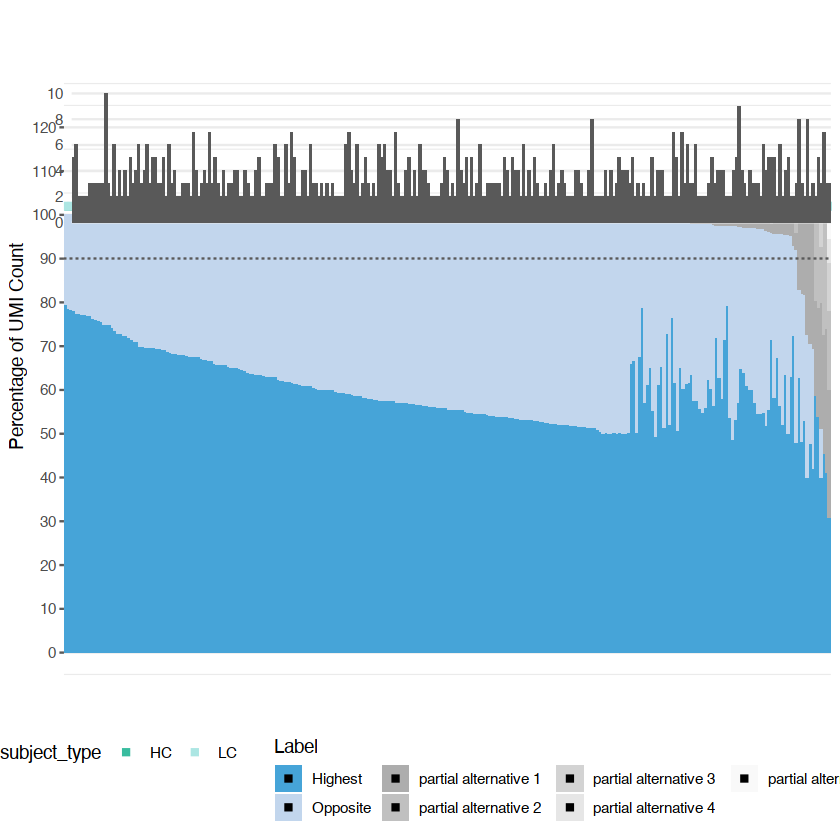

In [42]:
# Provided color codes
panel_A_colors <- c("#f69b70", "#f9c2a7", "#fde8df", "#b9e8ff", "#1cb6ff", "#0098e0")
panel_B_colors <- c( "#d3d3d3", "#3ac5a4", "#3c90be", "#394abe")

# Select distinct colors for "Highest" and "Opposite"
highest_color <- "#46a4d8" # A strong blue
opposite_color <- "#c2d6ed"   

# Select a base color for the "partialalt" labels and generate shades

partialalt_shades <- colorRampPalette(c("#adadad", "#f9f9f9"))(5)  # Assuming 4 partialalt labels

# Define the custom color palette
custom_colors <- c("Highest" = highest_color, "Opposite" = opposite_color, 
                   setNames(partialalt_shades, paste("partial alternative", 1:5)))

# Define colors for HC and LC
hc_lc_colors <- c("HC" = "#39bc9f", "LC" = "#ace6e3")

# Add subject_type_color column based on the 'subject' ending 
df <- df  %>% 
   mutate(cell_chain=paste0(cell,"_",subject_type))

# Summarize umi_percentage for 'Highest' label
summarized_data <- df %>% 
  filter(label == "Highest" | label == "Opposite") %>%
  group_by(cell_chain) %>%
  summarise(total_umi_per = sum(umi_percentage),highest_umi = max(umi_percentage[label == "Highest"]) ) %>%
  arrange(desc(total_umi_per), desc(highest_umi))

summarized_data <- read.csv("summarized_data_order.csv")

# Adjust the levels of the factor for 'cell' based on 'total_umi'
df$cell_chain <- factor(df$cell_chain, levels = summarized_data$cell_chain)

# Create the plot
ggplot_object <- ggplot(df, aes(x = cell_chain, y = umi_percentage, fill = label)) + #reorder(cell, cell_order)
  geom_bar(stat = "identity", position=position_stack(reverse = TRUE)) +
  scale_fill_manual(values = custom_colors) +
  geom_point(data = df, aes(x = cell_chain, y = 102, color = subject_type), 
             size = 2, shape = 15) +  # Using square shape for the points
  scale_color_manual(values = hc_lc_colors) +
  labs(x = "", y = "Percentage of UMI Count") +
  theme_minimal() +
  theme(axis.text.x = element_blank(),
        legend.position = "bottom",
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.ticks.y = element_line(color= "#595959",
                                  linewidth = 0.5)) +
  guides(fill = guide_legend(title = "Label", title.position = "top")) +
  scale_y_continuous(limits = c(0, 140), breaks = seq(0, 124, by = 10)) +
  geom_hline(yintercept = 90, linetype = "33", color = "#595959") 

# Calculate the summary for position_count
summary_position_count <- df %>%
  group_by(cell_chain) %>%
  summarise(avg_position_count = mean(position_count))  # or use sum, max, etc.

# Adjust the levels of the factor for 'cell' based on 'total_umi'
summary_position_count$cell_chain <- factor(summary_position_count$cell_chain, levels = summarized_data$cell_chain)

small_plot <- ggplot(summary_position_count, aes(x = cell_chain, y = avg_position_count)) +
  geom_bar(stat = "identity") +
   scale_y_continuous(limits = c(0, 10), 
                     breaks = seq(0, 10, by = 5)) +  # Adjust y-axis limits and expansion
  theme_minimal() +  # Use a minimal theme as a base
  theme(
    axis.title.x = element_blank(),  # Remove x-axis title
    axis.title.y = element_blank(),
    axis.text.x = element_blank(),  # Remove x-axis text
    axis.ticks.x = element_blank(),  # Remove x-axis ticks
    plot.margin = margin(1, 0, 1, -0.35, "cm"),
            panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
  panel.grid.major.y = element_line(),  # Remove major y-axis grid lines
    panel.grid.minor.y = element_blank()  # Remove minor y-axis grid lines
) +  scale_y_continuous(limits = c(0, max(summary_position_count$avg_position_count)),  # Set y-axis limits dynamically
                     breaks = seq(0, max(summary_position_count$avg_position_count), 2))   # More breaks on y-axis

# Create a grob (graphic object) from the small plot
small_grob <- ggplotGrob(small_plot)

# Embed the small plot on top of the main plot
ggplot_object <- ggplot_object +
  annotation_custom(grob = small_grob, xmin = -Inf, xmax = Inf, ymin = 85, ymax = 140) 

# Print the plot
print(ggplot_object)

ggsave("figs_paper/umi_combination.pdf", plot = ggplot_object, width = 17.5, height = 12, units = "cm")

In [43]:

# Function to split the combination into position-letter pairs
split_combination <- function(combination) {
  str_split(combination, ",\\s*")[[1]] %>%
    map(~str_split(., ":")[[1]][2])  # Extract only the nucleotide letters
}

# Function to compare combinations and count matches
compare_and_count_matches <- function(highest_comb, other_comb) {
  # Split into position-letter pairs
  highest_pairs <- split_combination(highest_comb)
  other_pairs <- split_combination(other_comb)

  # Count matches
  sum(mapply(`==`, highest_pairs, other_pairs))
}

# Process the data
comparison_results <- df %>%
  group_by(subject, cell) %>%
  filter(any(label == "Highest")) %>%
  reframe(
    highest_combination = nucl_combination[label == "Highest"][1],
    other_combination = c(nucl_combination[label == "Highest"][1], nucl_combination[label != "Highest"]),
            unique_combinations = unique_combinations[label == "Highest"],
    match_count = c(length(split_combination(nucl_combination[label == "Highest"][1])), 
                    map_int(nucl_combination[label != "Highest"], 
                            ~compare_and_count_matches(nucl_combination[label == "Highest"][1], .))),
    position_count = position_count[label == "Highest"],  # Retain position_count for the 'Highest'
      umi_percentage = umi_percentage,
      cell_chain=cell_chain
  ) %>%
  ungroup()

In [44]:
# View the results
comparison_results <- comparison_results %>% mutate(ummatch = (position_count-match_count)*1/position_count) 
head(comparison_results)

subject,cell,highest_combination,other_combination,unique_combinations,match_count,position_count,umi_percentage,cell_chain,ummatch
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<fct>,<dbl>
K1B_S10000-LC,AGCTTGACAATGGACG,"132:G, 160:C","132:G, 160:C",2,2,2,53.84615,AGCTTGACAATGGACG_LC,0
K1B_S10000-LC,AGCTTGACAATGGACG,"132:G, 160:C","132:A, 160:A",2,0,2,46.15385,AGCTTGACAATGGACG_LC,1
K1B_S144-LC,AAGGTTCGTTGTACAC,"262:C, 230:C","262:C, 230:C",2,2,2,57.50000,AAGGTTCGTTGTACAC_LC,0
K1B_S144-LC,AAGGTTCGTTGTACAC,"262:C, 230:C","262:A, 230:G",2,0,2,42.50000,AAGGTTCGTTGTACAC_LC,1
K1B_S144-LC,ACGCCAGAGGCATTGG,"284:T, 257:T, 131:T, 189:G, 200:G","284:T, 257:T, 131:T, 189:G, 200:G",2,5,5,54.83871,ACGCCAGAGGCATTGG_LC,0
K1B_S144-LC,ACGCCAGAGGCATTGG,"284:T, 257:T, 131:T, 189:G, 200:G","284:G, 257:G, 131:C, 189:A, 200:C",2,0,5,45.16129,ACGCCAGAGGCATTGG_LC,1


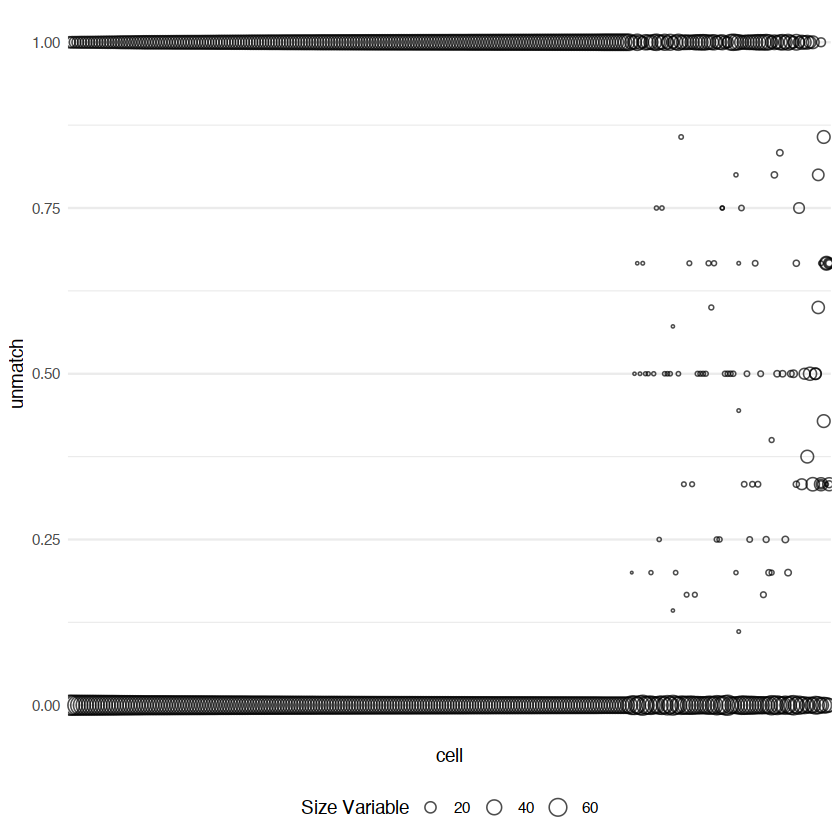

In [45]:

# Sample code for creating a dot plot
ggplot_object <- ggplot(comparison_results, aes(x = cell_chain, y = ummatch, size = umi_percentage)) +
  geom_point(alpha = 0.7, shape=1) +  # Adjust alpha for dot transparency if needed
  scale_size_continuous(name = "Size Variable", range = c(0.1, 5)) +  # Adjust the size range as needed
  labs(x = "cell", y = "unmatch") +
    theme_minimal() +
  theme(axis.text.x = element_blank(),
        legend.position = "bottom",
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank()) 

# Print the plot
print(ggplot_object)


ggsave("figs_paper/umi_combination_dotplot.pdf", plot = ggplot_object, width = 17.5, height = 7, units = "cm")

In [46]:
# new visualization

result <- df %>% group_by(cell_chain) %>%   summarize(
    sum_umi_percentage = sum(umi_percentage[(label == "Highest" | label == "Opposite")], na.rm = TRUE)
  )
head(result)

cell_chain,sum_umi_percentage
<fct>,<dbl>
CATCAAGCAGGATCGA_LC,100
ACGATACAGGAGCGAG_HC,100
CGTCACTCACCAGCAC_LC,100
GTTACAGGTCCGAAGA_LC,100
CAGCTAATCTTAACCT_LC,100
AGTTGGTCAGTAAGCG_HC,100


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


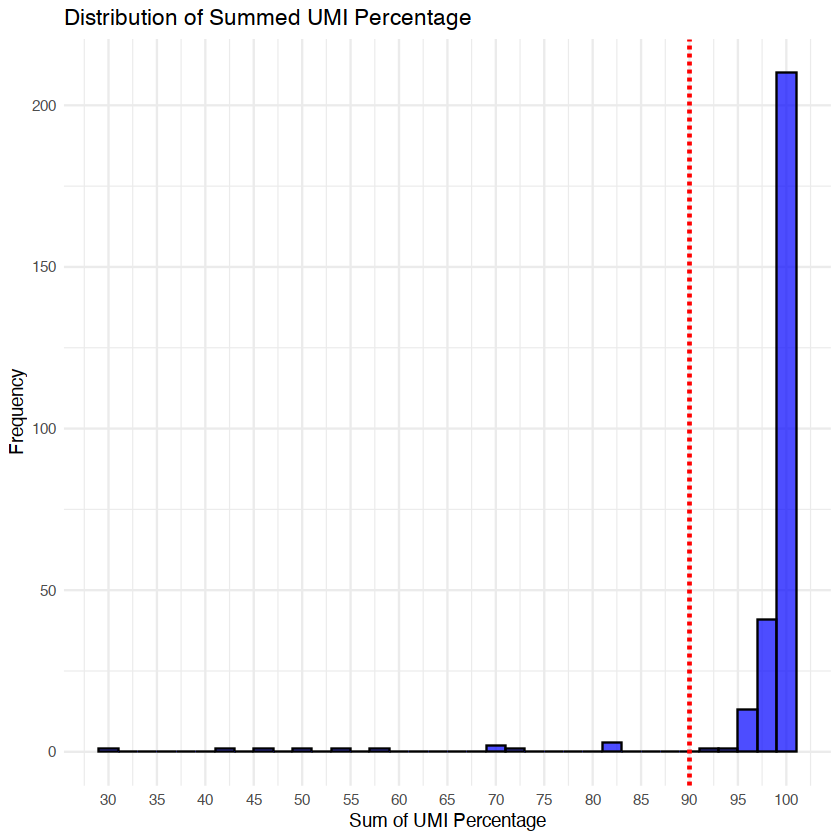

In [47]:

# Creating the plot
dis <- ggplot(result, aes(x = sum_umi_percentage)) +
  geom_histogram(binwidth = 2, fill = "blue", color = "black", alpha = 0.7) + # or geom_density() for a density plot
  geom_vline(xintercept = 90, color = "red", linetype = "dashed", size = 1) +
#geom_text(data = annotations, aes(x = midpoint, y = count, label = count), vjust = -0.5) +
  theme_minimal() +
  labs(title = "Distribution of Summed UMI Percentage",
       x = "Sum of UMI Percentage",
       y = "Frequency") +
scale_x_continuous(breaks = seq(30,100, by = 5))

dis
ggsave("figs_paper/umi_combination_distribution.pdf", plot = dis, width = 10, height = 7, units = "cm")

#### New PO classification

In [48]:
# Step 1: Identify groups with at least 'Highest' and 'Opposite' labels
valid_groups <- df %>%
  group_by(subject, cell) %>%
  filter(any(label == "Highest") & any(label == "Opposite")) %>%
  ungroup() %>%
  distinct(subject, cell)

# Step 2, 3, 4, and 5: Categorize each row
df <- df %>%
  rowwise() %>%
  mutate(categorized_label = if_else(
    (subject %in% valid_groups$subject) & (cell %in% valid_groups$cell),
    if_else(
      label %in% c("Highest", "Opposite"),
      {
        # Find the max match_percentage_po for 'Highest' and 'Opposite'
        max_po_highest <- max(df$match_percentage_po[df$subject == subject & df$cell == cell & df$label == "Highest"], na.rm = TRUE)
        max_po_opposite <- max(df$match_percentage_po[df$subject == subject & df$cell == cell & df$label == "Opposite"], na.rm = TRUE)

        if (max_po_highest == max_po_opposite && max_po_highest == 50) {
          "Undetermined"
        } else if (label == "Highest" && max_po_highest >= max_po_opposite) {
          "PO"
        } else if (label == "Opposite" && max_po_opposite > max_po_highest) {
          "PO"
        } else {
          "Neovariant"
        }
      },
      NA_character_
    ),
    "invalid"
  ))

Warning message:
“There were 19 warnings in `mutate()`.
The first warning was:
ℹ In argument: `categorized_label = if_else(...)`.
ℹ In row 139.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 18 remaining warnings.”


In [49]:
# Pivoting the data into a wide format

df <- df %>% group_by(subject, cell) %>%
  filter(!is.na(categorized_label), label %in% c("Highest", "Opposite")) %>%
  mutate(index = row_number()) %>%
  ungroup()

df_wide <- df %>% filter(!is.na(categorized_label)) %>% select(subject,cell,nucl_combination_po,nucl_combination,match_percentage_po,categorized_label,index) %>% 
  pivot_wider(
    id_cols = c(subject, cell,nucl_combination_po),
    names_from = index,
    names_sep = "",
    values_from = c(nucl_combination, categorized_label, match_percentage_po)
  )

In [50]:
# Function to expand the rows based on nucl_combinations to fit to master table format
expand_rows <- function(row) {
  n1 <- strsplit(as.character(row$nucl_combination1), ", ")[[1]]
  n2 <- strsplit(as.character(row$nucl_combination2), ", ")[[1]]
  
  data.frame(subject = row$subject, 
             cell = row$cell, 
             nucl_combination_po = row$nucl_combination_po, 
             nucl_combination_1 = row$nucl_combination1, 
             nucl_combination_2 = row$nucl_combination2, 
             nucl_combination1 = n1, 
             nucl_combination2 = n2, 
             categorized_label1 = row$categorized_label1, 
             categorized_label2 = row$categorized_label2, 
             match_percentage_po1 = row$match_percentage_po1, 
             match_percentage_po2 = row$match_percentage_po2)
}

# Applying the function to each row
df_expanded <- do.call(rbind, lapply(1:nrow(df_wide), function(i) expand_rows(df_wide[i, ])))

# Function to split nucleotide combinations into position and nucleotide
split_nucl_combination <- function(comb) {
  parts <- strsplit(comb, ":")[[1]]
  return(parts)
}

# Applying the function and expanding the DataFrame
df_final <- df_expanded %>%
  rowwise() %>%
  mutate(pos= as.numeric(split_nucl_combination(nucl_combination1)[1]),
         nucl1 = split_nucl_combination(nucl_combination1)[2],
         nucl2 = split_nucl_combination(nucl_combination2)[2]) %>% select(-nucl_combination1,-nucl_combination2) %>%
  ungroup()

In [51]:
head(df_final)

subject,cell,nucl_combination_po,nucl_combination_1,nucl_combination_2,categorized_label1,categorized_label2,match_percentage_po1,match_percentage_po2,pos,nucl1,nucl2
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
K7B_S10000-LC,CTGTGCTTCTATCCCG,"185:G, 153:G","185:A, 153:A","185:G, 153:G",Neovariant,PO,0,100,185,A,G
K7B_S10000-LC,CTGTGCTTCTATCCCG,"185:G, 153:G","185:A, 153:A","185:G, 153:G",Neovariant,PO,0,100,153,A,G
K6B_S13530-HC,TAGAGCTAGAGCCTAG,"324:C, 379:G, 255:C, 268:G, 301:T","324:C, 379:G, 255:C, 268:G, 301:A","324:A, 379:A, 255:T, 268:A, 301:G",PO,Neovariant,80,0,324,C,A
K6B_S13530-HC,TAGAGCTAGAGCCTAG,"324:C, 379:G, 255:C, 268:G, 301:T","324:C, 379:G, 255:C, 268:G, 301:A","324:A, 379:A, 255:T, 268:A, 301:G",PO,Neovariant,80,0,379,G,A
K6B_S13530-HC,TAGAGCTAGAGCCTAG,"324:C, 379:G, 255:C, 268:G, 301:T","324:C, 379:G, 255:C, 268:G, 301:A","324:A, 379:A, 255:T, 268:A, 301:G",PO,Neovariant,80,0,255,C,T
K6B_S13530-HC,TAGAGCTAGAGCCTAG,"324:C, 379:G, 255:C, 268:G, 301:T","324:C, 379:G, 255:C, 268:G, 301:A","324:A, 379:A, 255:T, 268:A, 301:G",PO,Neovariant,80,0,268,G,A


In [52]:
#pivot longer df to match event_v3

# Pivoting nucl and categorized_label columns simultaneously
df_longer <- df_final %>%
  pivot_longer(
    cols = starts_with("nucl"),
    names_to = "nucl_type",
    values_to = "nucl",
    names_pattern = "nucl(\\d)"
  ) %>%
  pivot_longer(
    cols = starts_with("categorized_label"),
    names_to = "categorized_label_type",
    values_to = "categorized_label",
    names_pattern = "categorized_label(\\d)"
  ) %>%
  filter(sub(".*_", "", nucl_type) == sub(".*_", "", categorized_label_type)) %>%
  select(-nucl_type, -categorized_label_type,-match_percentage_po1,-match_percentage_po2)

In [53]:
df_longer %>% pull(categorized_label) %>% table()

.
     invalid   Neovariant           PO Undetermined 
          13          799          806          300 

In [54]:
#create the columns original and neovariant1

# Creating new columns 'po' and 'neovariant' based on 'categorized_label'
df_transformed <- df_longer %>%
  group_by(subject, cell, pos) %>%
  mutate(undetermined_count = cumsum(categorized_label == "Undetermined"),
         original = ifelse(categorized_label == "PO", nucl, NA_character_),
         neovariant1 = ifelse(categorized_label == "Neovariant" | categorized_label == "unvalid" |(categorized_label == "Undetermined" & undetermined_count == 1), nucl, NA_character_),
         neovariant2 = ifelse(categorized_label == "Undetermined" & undetermined_count == 2, nucl, NA_character_)) %>%
  ungroup() %>%
  select(subject, cell, pos, original, neovariant1, neovariant2) %>%
  group_by(subject, cell, pos) %>%
  summarize(
    original = max(original, na.rm = TRUE),
    neovariant1 = max(neovariant1, na.rm = TRUE),
    neovariant2 = max(neovariant2, na.rm = TRUE),
    .groups = "drop"
  ) %>% dplyr::rename("position"="pos")

Warning message:
“There were 1002 warnings in `summarize()`.
The first warning was:
ℹ In argument: `original = max(original, na.rm = TRUE)`.
ℹ In group 45: `subject = "K1B_S144-LC"`, `cell = "CTGGTCTGTGTCAATC"`, `pos =
  313`.
Caused by warning in `max()`:
! no non-missing arguments, returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1001 remaining warnings.”


In [55]:
head(df_transformed) #%>% filter(cell == "CGTTGGGTCCTTTCTC")

subject,cell,position,original,neovariant1,neovariant2
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
K1B_S10000-LC,AGCTTGACAATGGACG,132,G,A,NA
K1B_S10000-LC,AGCTTGACAATGGACG,160,C,A,NA
K1B_S144-LC,AAGGTTCGTTGTACAC,230,G,C,NA
K1B_S144-LC,AAGGTTCGTTGTACAC,262,A,C,NA
K1B_S144-LC,ACGCCAGAGGCATTGG,131,T,C,NA
K1B_S144-LC,ACGCCAGAGGCATTGG,189,G,A,NA


In [56]:
df_transformed %>% group_by(subject) %>% summarize(different_cells = n())# %>% pull(different_cells) %>% sum()

subject,different_cells
<chr>,<int>
K1B_S10000-LC,2
K1B_S144-LC,74
K2B_S13530-LC,5
K2B_S13553-LC,4
K6B_S13530-HC,167
K6B_S13530-LC,148
K7B_S10000-HC,101
K7B_S10000-LC,203
K8B_S13553-LC,265


In [57]:
df_transformed %>% group_by(subject) %>% summarize(different_cells = n()) %>% pull(different_cells) %>% sum()

[1] 969

In [58]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
head(events_v31)

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,G,C,NA,45,79,NA,TRUE,4.387031,10000.1
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,A,C,NA,21,16,NA,TRUE,2.451408,10000.2
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,G,C,NA,16,14,NA,TRUE,2.720672,10000.2
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,NA,A,C,NA,12,13,TRUE,NA,10000.2
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,G,C,NA,12,14,NA,TRUE,3.346433,10000.2
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,G,A,NA,16,39,NA,TRUE,5.344081,10000.3


In [59]:
# Do not forget to annotate the invalid cell, the ones that have only one nucl (20 cells/gene)
#subset_n_event %>% filter(rowSums(is.na(select(., original_umis.y, neovariant1_umis.y, neovariant2_umis.y))) > 1)

In [60]:
#969 events
multiple_events <- events_v31 %>% inner_join(df_transformed %>% 
                          select(subject,cell,position,original,neovariant1,neovariant2), by=c("subject","cell","position")) %>% 
                          mutate(original_umis.y = case_when(original.y == original.x ~ original_umis,
                                                             original.y == neovariant1.x ~ neovariant1_umis,
                                                             original.y == neovariant2.x ~ neovariant2_umis,
                                                             TRUE ~ NA),
                                 neovariant1_umis.y = case_when(neovariant1.y == original.x ~ original_umis,
                                                             neovariant1.y == neovariant1.x ~ neovariant1_umis,
                                                             neovariant1.y == neovariant2.x ~ neovariant2_umis,
                                                             TRUE ~ NA),
                                 neovariant2_umis.y = case_when(neovariant2.y == original.x ~ original_umis,
                                                             neovariant2.y == neovariant1.x ~ neovariant1_umis,
                                                             neovariant2.y == neovariant2.x ~ neovariant2_umis,
                                                             TRUE ~ NA)) %>%
                 select(-original.x,-neovariant1.x,-neovariant2.x,-original_umis,-neovariant1_umis,-neovariant2_umis) %>%
                 dplyr:: rename("original"="original.y","neovariant1"="neovariant1.y","neovariant2"="neovariant2.y","original_umis"="original_umis.y","neovariant1_umis"="neovariant1_umis.y","neovariant2_umis"="neovariant2_umis.y")

In [61]:
# Do not forget to annotate the invalid cell, the ones that have only one nucl (20 cells)
#subset_n_event %>% filter(rowSums(is.na(select(., original_umis.y, neovariant1_umis.y, neovariant2_umis.y))) > 1)

In [62]:
single_events <- events_v31 %>% anti_join(multiple_events %>% 
                        select(subject,cell,position,original,neovariant1,neovariant2), by=c("subject","cell","position"))

In [63]:
single_events %>% filter(is.na(neovariant2)) %>% str()

tibble [256 × 24] (S3: tbl_df/tbl/data.frame)
 $ order                 : num [1:256] 1 15 16 17 18 19 20 21 22 23 ...
 $ Chip                  : chr [1:256] "K7B" "K7B" "K7B" "K7B" ...
 $ Sample                : chr [1:256] "S10000" "S10000" "S10000" "S10000" ...
 $ Ig Chain              : chr [1:256] "L" "L" "H" "H" ...
 $ V(D)Jmutations        : num [1:256] 1 1 2 2 1 1 3 3 3 2 ...
 $ VDJmutations          : num [1:256] 0 0 2 2 1 1 3 3 3 0 ...
 $ VJmutations           : num [1:256] 1 1 0 0 0 0 0 0 0 2 ...
 $ inBoth                : chr [1:256] "FALSE" "FALSE" "FALSE" "FALSE" ...
 $ Cell ident            : chr [1:256] "S10000.1" "S10000.1" "S10000.1" "S10000.2" ...
 $ subject               : chr [1:256] "K7B_S10000-LC" "K7B_S10000-LC" "K7B_S10000-HC" "K7B_S10000-HC" ...
 $ cell                  : chr [1:256] "AAAGATGGTCCGAGTC" "AACCGCGAGTGGTAAT" "AACGTTGCAGGAACGT" "AACGTTGCAGGAACGT" ...
 $ subregion             : chr [1:256] "FR1" "FR3" "FR2" "CDR3" ...
 $ position              : num [

In [64]:
#270 + 969 = 1239 events
events_v4 <- single_events %>% bind_rows(multiple_events)

In [65]:
head(events_v4)

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,G,C,NA,45,79,NA,TRUE,4.387031,10000.1
15,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AACCGCGAGTGGTAAT,FR3,348,240,CT.CA,C,G,NA,27,33,NA,TRUE,3.456010,10000.6
16,K7B,S10000,H,2,2,0,FALSE,S10000.1,K7B_S10000-HC,AACGTTGCAGGAACGT,FR2,226,102,AT.CA,G,A,NA,20,33,NA,TRUE,4.217978,10000.7
17,K7B,S10000,H,2,2,0,FALSE,S10000.2,K7B_S10000-HC,AACGTTGCAGGAACGT,CDR3,430,NA,TT.AG,A,G,NA,38,24,NA,TRUE,2.118807,10000.7
18,K7B,S10000,H,1,1,0,FALSE,S10000.1,K7B_S10000-HC,AAGCCGCAGGAGTACC,FR2,252,128,CA.GG,A,T,NA,25,18,NA,TRUE,2.347226,10000.8
19,K7B,S10000,H,1,1,0,FALSE,S10000.1,K7B_S10000-HC,AAGCCGCGTACTTGAC,FR2,243,119,GG.TC,C,G,NA,22,11,NA,TRUE,1.754888,10000.9


## 3. Calculate the timing of neovariant

In [66]:
events_v41 <- events_v4 %>% 
             mutate(h_from_event = log(original_umis/(original_umis+neovariant1_umis))/-0.231049) 

#### Include a numeric cell ID (n_cell_ID) and rerun index

In [67]:
# Extracting the ID numbers after "S" and creating a consecutive number according to the cellbarcode
events_v41 <- events_v41 %>% rowid_to_column("index") %>%
  mutate(sample_number = as.numeric(sub("S", "", Sample))) %>%
  group_by(sample_number) %>%
  mutate(n_cell_ID = paste(sample_number, dense_rank(cell), sep = ".")) %>%
  # mutate(n_cell_id_numeric = as.numeric(sub(".*\\.", "", n_cell_ID))) %>%
  # arrange(sample_number, n_cell_id_numeric) %>%
  select(-sample_number,-order)  #-n_cell_id_numeric

Adding missing grouping variables: `sample_number`


## 4. Incorporate Syn/NonSyn data (Check problem of UMIS with NA) 
### @Diego new output

In [68]:
## Load all SHMss events detected (positive + false positive)
df <- Sys.glob("input/results_20240104/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccicciiiicccccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

In [69]:
head(df)

cell,umi,position,cons_nucl,nucl,depth,region,subregion,vgene_position,vgene_position_aligned,dgene_position,jgene_position,productive,context,context_cc,codon_cc,productive_cc,aa_ref_cc,aa_alt_cc,nucl_po,subject
<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATCACGTA,GCAGGCAGTG,290,G,T,9,L,-,NA,NA,NA,NA,T,NN.TT,CA.CC,NA,T,NA,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,TAGCCGTATA,290,G,G,91,L,-,NA,NA,NA,NA,T,CA.CC,CA.CC,NA,T,NA,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,TCACTTGGCC,290,G,G,98,L,-,NA,NA,NA,NA,T,CA.CC,CA.CC,NA,T,NA,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,GCAGGCAGTG,291,C,T,9,L,-,NA,NA,NA,NA,T,NT.TC,AG.CC,NA,T,NA,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,TAGCCGTATA,291,C,C,91,L,-,NA,NA,NA,NA,T,AG.CC,AG.CC,NA,T,NA,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,TCACTTGGCC,291,C,C,98,L,-,NA,NA,NA,NA,T,AG.CC,AG.CC,NA,T,NA,NA,-,K1B_S10000-HC


In [70]:
df %>% pull(region) %>% table()

.
      C       D       J       L       N       V 
7409487   58469 1879122 5025332 1069985 9996208 

In [71]:
# df[df$cell == "CCGTACTTCATAGCAC" & df$position == 224, "subregion"] <- "FR2"
# df[df$cell == "GCATGCGCACCAGGCT" & df$position == 211, "subregion"] <- "FR2"
# df[df$cell == "AGTGTCACAGCTGGCT" & df$position == 203, "subregion"] <- "FR2"

In [72]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v5 <- events_v41 %>% left_join(df %>% select(subject,cell,region,subregion,position,dgene_position,jgene_position,codon_cc,aa_ref_cc,aa_alt_cc,nucl,context_cc,nucl_po), by=c("subject","cell","subregion","position")) %>% unique() %>% 
mutate(nucl_po = toupper(nucl_po)) %>% mutate(aminoacid_original=if_else(nucl == original,aa_alt_cc,NA)) %>% 
mutate(aminoacid_n1=if_else(nucl == neovariant1,aa_alt_cc,NA)) %>%
mutate(aminoacid_n2=if_else(nucl == neovariant2,aa_alt_cc,NA)) %>%
 group_by(index,Chip,Sample,`Ig Chain`,`V(D)Jmutations`,`VDJmutations`,
          `VJmutations`,`inBoth`,`Cell ident`,subject,cell,region,subregion,position,vgene_position_aligned,dgene_position,jgene_position,
          context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc) %>%
  summarise(
    aminoacid_original = na.omit(aminoacid_original)[1],
    aminoacid_n1 = na.omit(aminoacid_n1)[1],
    aminoacid_n2 = na.omit(aminoacid_n2)[1],
    .groups = 'drop' # to drop the grouping after summarising
  ) %>% mutate(
    mutation_type = case_when(
      aminoacid_original == aminoacid_n1 ~ "silent",
      (!is.na(aminoacid_original)) & aminoacid_n1 == "*" ~ "nonsense",
      aminoacid_original == "*" ~ "stop-loss",
      aminoacid_original != aminoacid_n1 ~ "missense",
      TRUE ~ NA_character_
    )
  )

In [73]:
events_v5 %>% filter(is.na(context_cc))
#events_v5 %>% filter(is.na(codon_cc))

index,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,region,subregion,position,vgene_position_aligned,dgene_position,jgene_position,context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>


In [74]:
events_v5 %>% pull(region) %>% table()

.
   D    J    V 
   3   58 1178 

## 5. Include modifications to master table like:
 - Generate full context (5 nt) 
 - Generate a full context (5 nt) for every neovariant 1 and 2 when there is not original
 - Calculate again the AID motif now using the cell context
- Define in which strand it was found the motif
 - Identify if the motif are destroyed with the neovariant

In [75]:
head(events_v5)

index,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,region,subregion,position,vgene_position_aligned,dgene_position,jgene_position,context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,V,FR1,136,28,NA,NA,CA.TG,CA.TG,G,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,XTG,V,L,NA,missense
2,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AACCGCGAGTGGTAAT,V,FR3,348,240,NA,NA,CT.CA,CT.CA,C,C,G,NA,27,33,NA,TRUE,3.456010,10000.6,CTX,L,L,NA,silent
3,K7B,S10000,H,2,2,0,FALSE,S10000.1,K7B_S10000-HC,AACGTTGCAGGAACGT,V,FR2,226,102,NA,NA,AT.CA,AT.CA,G,G,A,NA,20,33,NA,TRUE,4.217978,10000.7,ATX,M,I,NA,missense
4,K7B,S10000,H,2,2,0,FALSE,S10000.2,K7B_S10000-HC,AACGTTGCAGGAACGT,D,CDR3,430,NA,1,NA,TT.AG,TT.AG,A,A,G,NA,38,24,NA,TRUE,2.118807,10000.7,TTX,L,L,NA,silent
5,K7B,S10000,H,1,1,0,FALSE,S10000.1,K7B_S10000-HC,AAGCCGCAGGAGTACC,V,FR2,252,128,NA,NA,CA.GG,CA.GG,A,A,T,NA,25,18,NA,TRUE,2.347226,10000.8,AXG,K,M,NA,missense
6,K7B,S10000,H,1,1,0,FALSE,S10000.1,K7B_S10000-HC,AAGCCGCGTACTTGAC,V,FR2,243,119,NA,NA,GG.TC,GG.TC,C,C,G,NA,22,11,NA,TRUE,1.754888,10000.9,GXT,A,G,NA,missense


In [76]:
# Check how variation delete is calculated and maybe create a new column call substitution that is better for the analysis

In [77]:
# Generate full context (5 nt) and also with context_cc
events_v51 <- events_v5 %>%
              mutate(context_po_coding_strand = stri_replace_first_fixed(context_po, ".", nucl_po)) %>% 
              mutate(context_cc_po = stri_replace_first_fixed(context_cc, ".", original)) %>% 
              mutate(variation_delete = case_when(is.na(original) ~ NA, !is.na(original) ~ paste0(original,"-",neovariant1))) %>% #the one that is possible to define hierarchy, if not is NA
              mutate(variation_delete2 = case_when(is.na(original) ~ paste0(neovariant1,"-",neovariant2), !is.na(original) ~ NA)) #this ones do not have hierarchy ins only neo1-neo2

### Identify AID motifs

In [78]:
# Modification of AID motif to identify motif forward and reverse
aidp2 <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT].")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."))
)

In [79]:
# Function to get reverse complement, handles NA
get_rev_comp <- function(s) {
  if (is.na(s)) return(NA)
  dna_s <- DNAString(s)
  return(as.character(reverseComplement(dna_s)))
}

# Custom function to get complement without reversing
get_complement <- function(seq) {
  # Define the complement mapping
  complement_map <- c("A" = "T", "T" = "A", "G" = "C", "C" = "G", "-" = "-", "N" = "N")
  
  # Convert sequence string to character vector
  seq_vector <- strsplit(seq, '')[[1]]
  
  # Find the complement using the mapping
  complement_vector <- complement_map[seq_vector]
  
  # Convert back to a single string
  complement_seq <- paste0(complement_vector, collapse = "")
  
  return(complement_seq)
}

In [80]:
identify_aid_patterns_bystrand <- function(mutation, context, aid_patterns = aidp2) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [81]:
#Define AID motifs from consensus cell context (only for variation where is possible to define hierarchy)
events_v51$original_aid_motif1 <- mapply(identify_aid_patterns_bystrand, events_v51$variation_delete, events_v51$context_cc)
events_v51$original_aid_motif2 <- mapply(identify_aid_patterns_bystrand, sapply(events_v51$variation_delete, get_complement), sapply(events_v51$context_cc, get_rev_comp))

events_v51$neovariant_aid_motif1 <- mapply(identify_aid_patterns_bystrand, sapply(events_v51$variation_delete, reverse), events_v51$context_cc)
events_v51$neovariant_aid_motif2 <- mapply(identify_aid_patterns_bystrand, sapply(sapply(events_v51$variation_delete, reverse),get_complement), sapply(events_v51$context_cc, get_rev_comp))

In [82]:
#Define AID motifs from consensus cell context when there is not original nucleotide

# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

reverse_string <- function(x) {
  if (is.na(x)) {
    return(NA)
  }
  elements <- strsplit(x, "-")[[1]]
  reversed_elements <- rev(elements)
  return(paste(reversed_elements, collapse = "-"))
}

# Calculate AID motif for context cc with neovariant 1 or neovariant 2
events_v51$neovariant_1_aid_motif <- mapply(identify_aid_patterns, events_v51$variation_delete2, events_v51$context_cc)
events_v51$neovariant_2_aid_motif <- mapply(identify_aid_patterns, sapply(events_v51$variation_delete2, reverse_string), events_v51$context_cc)

In [83]:
# Rank motifs
events_v52 <- events_v51 %>% 
  mutate(original_aid_motif = case_when(is.na(original) ~ "Not_evaluated",
    original_aid_motif1 == "WRCY" | original_aid_motif2 == "WRCY" ~ "WRCY",
    original_aid_motif1 == "WA" | original_aid_motif2 == "WA" ~ "WA",
    original_aid_motif1 == "RCG" | original_aid_motif2 == "RCG" ~ "RCG",
    original_aid_motif1 == "None" | original_aid_motif2 == "None" ~ "None",
    TRUE ~ NA
  )) %>%  
    mutate(neovariant_aid_motif = case_when(
    is.na(original) ~ "Not_evaluated",
    neovariant_aid_motif1 == "WRCY" | neovariant_aid_motif2 == "WRCY" ~ "WRCY",
    neovariant_aid_motif1 == "WA" | neovariant_aid_motif2 == "WA" ~ "WA",
    neovariant_aid_motif1 == "RCG" | neovariant_aid_motif2 == "RCG" ~ "RCG",
    neovariant_aid_motif1 == "None" | neovariant_aid_motif2 == "None" ~ "None",
    TRUE ~ NA
  )) %>% 
  mutate(motif_destroyed_original = case_when(
    original_aid_motif == "None"  ~ "No_motif", #& neovariant_aid_motif == "None"
        is.na(variation_delete) ~ "No_evaluated",
    original_aid_motif == neovariant_aid_motif ~ "FALSE",
    !is.na(original_aid_motif) & is.na(neovariant_aid_motif) ~ "TRUE",
    original_aid_motif != neovariant_aid_motif ~ "TRUE",
    is.na(original_aid_motif) ~ "No_motif",
    TRUE ~ "Other" # catches all other cases, can be removed if not needed
  ))  %>%
  mutate(strand_of_motif = case_when(
    original_aid_motif1 != "None" ~ "coding",
    original_aid_motif2 != "None" ~ "non-coding",
    is.na(original) ~ "Not_evaluated",
    original_aid_motif1 == "None" & original_aid_motif2 == "None" ~ "No-motif",
    TRUE ~ "Other"  # For any other cases, can be removed if not needed
   )) %>%
  mutate(motif_destroyed_neovariant = case_when(
    neovariant_aid_motif == "None"  ~ "No_motif",
        is.na(original) ~ "No_evaluated",
    original_aid_motif == neovariant_aid_motif ~ "FALSE",
    !is.na(original_aid_motif) & is.na(neovariant_aid_motif) ~ "TRUE",
    original_aid_motif != neovariant_aid_motif ~ "TRUE",
    is.na(neovariant_aid_motif) ~ "No_motif",
    TRUE ~ "Other" # catches all other cases, can be removed if not needed
  ))  

In [84]:
#delete all the columns that I do not need more
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v53 <- events_v52 %>% select(-`Cell ident`,-context_po,-context_cc,-variation_delete2,-original_aid_motif1,-original_aid_motif2,-neovariant_aid_motif1,-neovariant_aid_motif2,
                       -neovariant_1_aid_motif,-neovariant_2_aid_motif,
                      -context_po,-context_cc, -subject)

### tidy data for excel

In [85]:
# reorder  n_cell_id
events_v53 <- events_v53 %>% select(-index) %>%
  mutate(sample_number = as.numeric(sub("S", "", Sample))) %>%
  group_by(sample_number) %>%
  mutate(n_cell_ID = paste(sample_number, dense_rank(cell), sep = ".")) %>% 
  mutate(n_cell_id_numeric = as.numeric(sub(".*\\.", "", n_cell_ID))) %>%
  arrange(sample_number, n_cell_id_numeric) %>% rowid_to_column("order") %>% ungroup %>% select(-sample_number,-n_cell_id_numeric)

In [86]:
# include VDJ_position column and reorder columns
events_v53 <- events_v53 %>%
              mutate(
    VDJ_position = case_when(
      !is.na(vgene_position_aligned) ~ vgene_position_aligned,
      !is.na(dgene_position) ~ dgene_position,
      !is.na(jgene_position) ~ jgene_position,
      TRUE ~ NA_real_  # Default case if all values are NA
    )
  )  %>% select(-vgene_position_aligned,-dgene_position,jgene_position,order:position, VDJ_position, everything())  %>% select(order:Sample, n_cell_ID, everything())

#### Calculations of neovariant events in V region without CDR3

#### Cell IGHV

In [87]:
cells_IGHV <- events_v53 %>% filter(region == "V", subregion != "CDR3", is.na(neovariant2),VDJmutations > 0) %>% 
    group_by(Sample,Chip) %>%
    summarise(neovariant_cells = n_distinct(cell))

cells_IGHV 

`summarise()` has grouped output by 'Sample'. You can override using the
`.groups` argument.


Sample,Chip,neovariant_cells
<chr>,<chr>,<int>
S10000,K7B,45
S12500,K2B,1
S13530,K6B,51
S8934,K4B,3


#### Neovariant IGHV

In [88]:
neovariant_IGHV <- events_v53 %>% filter(region == "V", subregion != "CDR3", is.na(neovariant2),VDJmutations > 0) %>% 
  group_by(Sample) %>%
  summarise(n_events = n())

neovariant_IGHV 

Sample,n_events
<chr>,<int>
S10000,105
S12500,1
S13530,159
S8934,3


#### Cell IGLV

In [89]:
cells_IGLV <- events_v53 %>% filter(region == "V", subregion != "CDR3", is.na(neovariant2),VJmutations > 0) %>% 
    group_by(Sample) %>%
    summarise(neovariant_cells = n_distinct(cell))

cells_IGLV 

Sample,neovariant_cells
<chr>,<int>
S10000,76
S11770,1
S12500,1
S13530,46
S13553,91
S144,32


#### Neovariant IGHV

In [90]:
neovariant_IGHV <- events_v53 %>% filter(region == "V", subregion != "CDR3", is.na(neovariant2),VJmutations > 0) %>% 
  group_by(Sample) %>%
  summarise(n_events = n())

neovariant_IGHV 

Sample,n_events
<chr>,<int>
S10000,187
S11770,1
S12500,1
S13530,137
S13553,275
S144,78


In [91]:
# WriteXLS::WriteXLS(events_v53,
#                     "output/working_table.v5.3.xlsx")

### Alluvial analysis

In [92]:
data_alluvial <- events_v53 %>% filter(!original_aid_motif %in% c("Not_evaluated", "None")) %>% group_by(original_aid_motif,motif_destroyed_original) %>% count()
data_alluvial

original_aid_motif,motif_destroyed_original,n
<chr>,<chr>,<int>
RCG,TRUE,27
WA,FALSE,19
WA,TRUE,193
WRCY,FALSE,61
WRCY,TRUE,233


In [93]:
data_alluvial %>% filter(motif_destroyed_original == "TRUE") %>% pull(n) %>% sum()

[1] 453

In [94]:
# Assign colors directly in the dataframe
data_alluvial$color <- case_when(
  data_alluvial$original_aid_motif == "RCG" ~ "#3ac5a4",
  data_alluvial$original_aid_motif == "WA" ~ "#3c90be",
  data_alluvial$original_aid_motif == "WRCY" ~ "#394abe",
  TRUE ~ NA_character_  # Default, can be transparent (NA) or any color
)

your_data <- data_alluvial

# Define the order you want for original_aid_motif
desired_order <- c("WRCY", "WA", "RCG")

# Set the levels of original_aid_motif according to the desired order
your_data$original_aid_motif <- factor(your_data$original_aid_motif, levels = desired_order)

ao <- ggplot(your_data, 
       aes(axis1 = original_aid_motif, axis2 = motif_destroyed_original, y = n)) +
  geom_alluvium(aes(fill = color), width = 1/12) +
  geom_stratum(width = 1/12, size = 1, fill = NA,linewidth=0.5) +  # Keep the second stratum transparent
#  scale_fill_brewer(palette = "Set1") +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.y = element_blank(),
    axis.text.x = element_blank(),
    axis.title = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank()
  )  +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 3)

# ggsave("figs_paper/alluvial_original_motif.png", plot = ao, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/alluvial_original_motif.pdf", plot = ao, width = 7, height = 7, units = "cm")

In [95]:
data_alluvial_v2 <- events_v53 %>% filter(!neovariant_aid_motif %in% c("Not_evaluated", "None")) %>% group_by(neovariant_aid_motif,motif_destroyed_neovariant) %>% count()
data_alluvial_v2

neovariant_aid_motif,motif_destroyed_neovariant,n
<chr>,<chr>,<int>
RCG,TRUE,33
WA,FALSE,19
WA,TRUE,343
WRCY,FALSE,61
WRCY,TRUE,105


In [96]:
data_alluvial_v2 %>% pull(n) %>% sum() #filter(motif_destroyed_neovariant == "TRUE")

[1] 561

In [97]:
# Assign colors directly in the dataframe
data_alluvial_v2$color <- case_when(
  data_alluvial_v2$neovariant_aid_motif == "RCG" ~ "#3ac5a4",
  data_alluvial_v2$neovariant_aid_motif == "WA" ~ "#3c90be",
  data_alluvial_v2$neovariant_aid_motif == "WRCY" ~ "#394abe",
  TRUE ~ NA_character_  # Default, can be transparent (NA) or any color
)

your_data <- data_alluvial_v2

# Define the order you want for original_aid_motif
desired_order <- c("WRCY", "WA", "RCG")

# Set the levels of original_aid_motif according to the desired order
your_data$neovariant_aid_motif <- factor(your_data$neovariant_aid_motif, levels = desired_order)

ao <- ggplot(your_data, 
       aes(axis1 = neovariant_aid_motif, axis2 = motif_destroyed_neovariant, y = n)) +
  geom_alluvium(aes(fill = color), width = 1/12) +
  geom_stratum(width = 1/12, size = 1, fill = NA,linewidth=0.5) +  # Keep the second stratum transparent
#  scale_fill_brewer(palette = "Set1") +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.y = element_blank(),
    axis.text.x = element_blank(),
    axis.title = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank()
  )  +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 3)

# ggsave("figs_paper/alluvial_neovariant_motif.png", plot = ao, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/alluvial_neovariant_motif.pdf", plot = ao, width = 7, height = 7, units = "cm")


### Neovariants data (save some code)

In [98]:
AID_motif_summ <- events_v53 %>% filter(!is.na(original)) %>% group_by(original_aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(original_aid_motif == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="original_aid_motif") %>% mutate(group = "original")
AID_motif_summ

Motifs,n,Percentage,AID,group
<chr>,<int>,<dbl>,<chr>,<chr>
None,529,49.811676,No,original
RCG,27,2.542373,Yes,original
WA,212,19.962335,Yes,original
WRCY,294,27.683616,Yes,original


In [99]:
print('% AID-related motifs in FL neovariants (original)')
AID_motif_summ %>% 
  filter(Motifs != "None") %>%
  summarise(total_percentage = sum(Percentage)) %>% pull(total_percentage)

[1] "% AID-related motifs in FL neovariants (original)"


[1] 50.18832

In [100]:
AID_motif_summ_n <- events_v53 %>% filter(!is.na(original)) %>% group_by(neovariant_aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(neovariant_aid_motif == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="neovariant_aid_motif")  %>% mutate(group = "neovariant")
AID_motif_summ_n

Motifs,n,Percentage,AID,group
<chr>,<int>,<dbl>,<chr>,<chr>
None,501,47.175141,No,neovariant
RCG,33,3.107345,Yes,neovariant
WA,362,34.086629,Yes,neovariant
WRCY,166,15.630885,Yes,neovariant


In [101]:
print('% AID-related motifs in FL neovariants (neovariant)')
AID_motif_summ_n %>% 
  filter(Motifs != "None") %>%
  summarise(total_percentage = sum(Percentage)) %>% pull(total_percentage)

[1] "% AID-related motifs in FL neovariants (neovariant)"


[1] 52.82486

In [102]:
AID_motif_all <- AID_motif_summ %>% bind_rows(AID_motif_summ_n)

In [103]:
AID_motif_all

Motifs,n,Percentage,AID,group
<chr>,<int>,<dbl>,<chr>,<chr>
None,529,49.811676,No,original
RCG,27,2.542373,Yes,original
WA,212,19.962335,Yes,original
WRCY,294,27.683616,Yes,original
None,501,47.175141,No,neovariant
RCG,33,3.107345,Yes,neovariant
WA,362,34.086629,Yes,neovariant
WRCY,166,15.630885,Yes,neovariant


In [104]:
purpleish = c("#B4617A", "#7266ae","#a09ece","#d9dbd5")

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


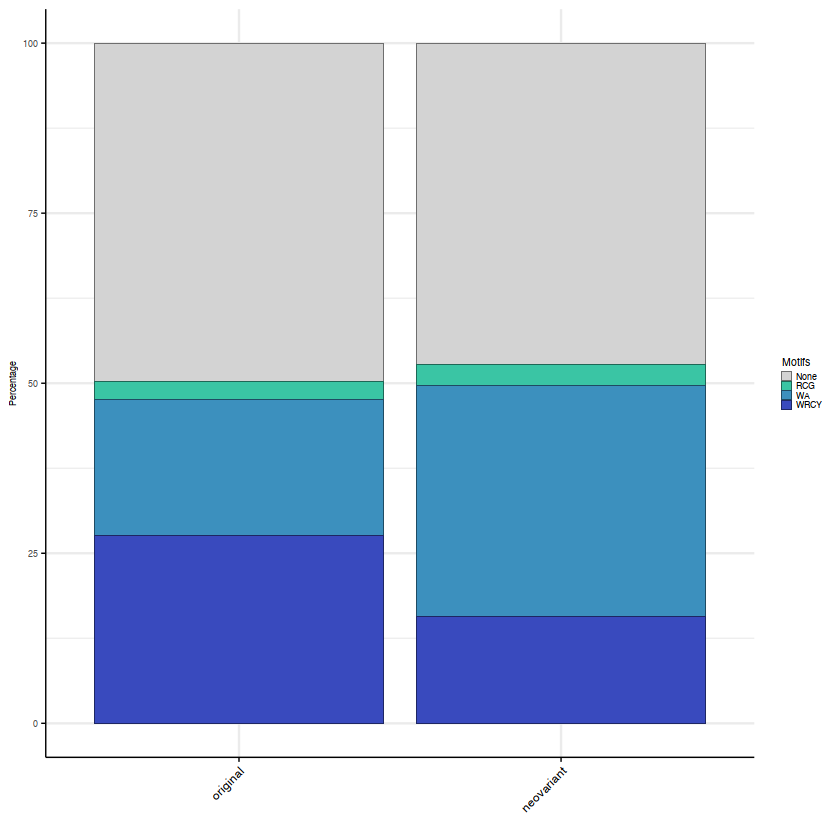

In [105]:
# Convert to factor to ensure the order of the bars
AID_motif_all$group <- factor(AID_motif_all$group, levels = c("original", "neovariant"))

# Create the stacked bar plot
p <- ggplot(AID_motif_all, aes(x = group, y = Percentage, fill = Motifs)) +
  geom_bar(stat = "identity",color="black",linewidth=0.1) +
  scale_fill_manual(values = c("None" = "#d3d3d3", "RCG" = "#3ac5a4", "WA" = "#3c90be", "WRCY" = "#394abe")) +
  theme_minimal() +
  theme(text = element_text(color = "black"),
    axis.title.x = element_text(size = 7, face = "bold",color = "black"),
    axis.title.y = element_text(size = 5, face = "bold",color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7,color = "black"),
    axis.text.y = element_text(size = 5),
    legend.title = element_text(size = 6),
    legend.text = element_text(size = 5),
    legend.box.margin = margin(0, 0, 0, 0),  # Reduce margin around legend
    axis.line = element_line(linewidt = 0.3, colour = "black", linetype=1),
    axis.ticks = element_line(size = 0.3, color="black"),
  ) +
  labs(fill = "Motifs", x = "", y = "Percentage") +
  guides(fill = guide_legend(title.position = "top"))

# Remove the plot title
p <- p + theme(plot.title = element_blank())

# Increase the legend size (this is a bit tricky in ggplot2 but can be done through theme updates)
p <- p + theme(legend.key.size = unit(0.4, 'lines'))

# Adjust the size of the saved plot
ggsave("figs_paper/AID_bar_plot.png", plot = p, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/AID_bar_plot.pdf", plot = p, width = 7, height = 7, units = "cm")

# Print the plot to the R console
print(p)


### IG from bulk data (mutational signature paper) 26 FL samples (-7 LUMC FL)

In [106]:
mutations_ig <- read.csv("../FL-CLL-MBL_filter/new_analysis_2020/ig_subset/data/df_ct_context.csv") %>% filter(lymph == "FL") %>% mutate(variation=paste0(ref,"-",alt))

In [107]:
head(mutations_ig)

,sample,lymph,chrom,pos,ref,alt,context2,context,substitution,variation
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FL_01_1,FL,14,105863138,T,C,AA.GC,A.G,T>C,T-C
2,FL_01_1,FL,14,105863282,C,G,TC.TC,C.T,C>G,C-G
3,FL_01_1,FL,14,105863293,A,G,TT.TG,T.T,T>C,A-G
4,FL_01_1,FL,14,105863314,C,G,AC.TT,C.T,C>G,C-G
5,FL_01_1,FL,14,105863315,T,A,CC.TC,C.T,T>A,T-A
6,FL_01_1,FL,14,105863340,G,T,AG.TT,G.T,C>A,G-T


#### Include AID motifs (check from here, which code to identify motfs I should use?)

In [108]:
mutations_ig$aid_motif <- mapply(identify_aid_patterns, mutations_ig$variation, mutations_ig$context2)

#### Filter out 7 samples from FL (present in single cell data) and rank motifs

In [109]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig <- mutations_ig %>% filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'))

In [110]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [111]:
AID_motif_wes <-mutations_ig %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_wes

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,389,46.642686,Yes
RCG,17,2.038369,Yes
WA,248,29.736211,Yes
WRCY,180,21.582734,Yes


In [112]:
print('% AID-related motifs in FL bulk')
AID_motif_wes %>% 
  filter(Motifs != "None") %>%
  summarise(total_percentage = sum(Percentage)) %>% pull(total_percentage)

[1] "% AID-related motifs in FL bulk"


[1] 53.35731

### IG from bulk data from Marcelo data

In [113]:
mutations_ig_m <- read.csv("input/igh_sanger_variant_analysis.csv")

In [114]:
mutations_ig_m <- mutations_ig_m %>% mutate(variation = paste0(ref,"-",alt)) 

In [115]:
head(mutations_ig_m)

,sample,V,D,J,pos,ref,alt,context,sig,variant,read_depth,ref_depth,alt_depth,allelic_depth,variation
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,10,C,T,AG.TG,WRCY,C/T,8,0,8,T:8,C-T
2,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,22,G,C,CC.GG,None,G/C,8,6,2,C:2,G-C
3,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,30,C,T,GG.TT,WRCY,C/T,8,6,2,T:2,C-T
4,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,89,G,C,CA.TA,WRCY,G/C,8,0,8,C:8,G-C
5,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,92,G,C,TA.CT,WRCY,G/C,8,0,8,C:8,G-C
6,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,93,C,T,AG.TA,WRCY,C/T,8,0,8,T:8,C-T


In [116]:
mutations_ig_m$aid_motif1 <- mapply(identify_aid_patterns, mutations_ig_m$variation, mutations_ig_m$context)
mutations_ig_m$aid_motif2 <- mapply(identify_aid_patterns, reverse(mutations_ig_m$variation), mutations_ig_m$context)

#### Rank motifs

In [117]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig_m <- mutations_ig_m %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) 

In [118]:
AID_motif_m <-mutations_ig_m %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,208,8.602151,Yes
WA,915,37.841191,Yes
WRCY,693,28.660050,Yes
NA,602,24.896609,No


In [119]:
AID_motif_m <-mutations_ig_m %>%  group_by(sig) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(sig == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("sig"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,1010,41.770058,No
RCG,110,4.549214,Yes
WA,444,18.362283,Yes
WRCY,854,35.318445,Yes


In [120]:
print('% AID-related motifs in FL bulk')
AID_motif_m %>% 
  filter(Motifs != "None") %>%
  summarise(total_percentage = sum(Percentage)) %>% pull(total_percentage)

[1] "% AID-related motifs in FL bulk"


[1] 58.22994

#### AID mutations between FL neovariant and FL (bulk)

#### Calculate p-value by motif

In [121]:
# # Calculate total counts of 'n' for each source
# total_counts <- AID_motifs %>% 
#   group_by(Source) %>% 
#   summarise(total_n = sum(n), .groups = "keep")

# # Join total counts with the original data
# AID_motifs <- AID_motifs %>%
#   left_join(total_counts, by = "Source")

# # Calculate counts for 'other' motifs
# AID_motifs$other_n <- AID_motifs$total_n - AID_motifs$n

# # Perform chi-squared test for each motif separately
# results <- AID_motifs %>% 
#   split(.$Motifs) %>% 
#   map_df(~{
#     test_result <- chisq.test(matrix(c(.$n, .$other_n), nrow = 2))
#     tibble(Motifs = unique(.$Motifs), p_value = test_result$p.value)
#   })

# # Join p-values with the original data
# AID_motifs <- AID_motifs %>%
#   left_join(results, by = "Motifs")


## 6. Substitution type (spectrum)

### Six Substituion pattern of all variant in 10x data

In [122]:
#clonotype information for K45678B
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv") %>% mutate(cell = gsub(".{2}$", "", barcode)) %>% 
 #            select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,seqConcClone, ,cluster,seqConcCount)  %>% 
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                     chain == "IGK" | chain == "IGL" ~ "LC",
                                    TRUE ~ "NA"))

In [123]:
#clonotype information for K123B
clonotype_K13B <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesMulti_2022_06_09.csv") %>% mutate(source=paste0(source,"_",subject))

In [124]:
# default pairwise alignment
# to use for variable tasks
pairwiseAlignmentPreset <- function( pattern, subject, score ) {
  alignment <- pairwiseAlignment( pattern = pattern,
                                  subject = subject,
                                  type = "local",
                                  substitutionMatrix = nucleotideSubstitutionMatrix( match = 1,
                                                                                     mismatch = 0,
                                                                                     baseOnly = FALSE ),
                                  gapOpening = 5,
                                  gapExtension = 2,
                                  scoreOnly = score )
  return( alignment ) }

In [125]:
perform_alignment_analysis <- function(input_df, output_file = "final_output_distinct.csv",
                                       source_col = 'source', chain_col = 'chain', seqClone_col = 'seqClone',
                                       contigId_col = 'contigId', seq_col = 'seq', score = FALSE) {
  # Initialize an empty data frame to store results
  final_output <- data.frame()
  
  # Fetch unique sources and chains
  unique_sources <- unique(input_df[[source_col]])
  unique_chains <- unique(input_df[[chain_col]])
  
  # Iterate over each unique source, chain, and seqClone
  for (src in unique_sources) {
    for (chn in unique_chains) {
      
      # Fetch the reference sequence (seqClone == 0 and contigId == "PO")
      ref_seq <- subset(input_df, input_df[[source_col]] == src & 
                                  input_df[[chain_col]] == chn & 
                                  input_df[[seqClone_col]] == 0 & 
                                  input_df[[contigId_col]] %like% "PO")[[seq_col]]
      
      if (length(ref_seq) == 0) next # Skip if no reference sequence
      
      # Fetch unique seqClone values, ignoring NA
      seqClones <- na.omit(unique(subset(input_df, input_df[[source_col]] == src & 
                                                  input_df[[chain_col]] == chn)[[seqClone_col]]))
      
      for (scl in seqClones) {
        if (scl == 0) next # Skip reference seqClone
        
        # Fetch the test sequence (ignoring NA and taking only the first sequence for each seqClone)
        test_seq <- na.omit(subset(input_df, input_df[[source_col]] == src & 
                                             input_df[[chain_col]] == chn & 
                                             input_df[[seqClone_col]] == scl)[[seq_col]])[1]
        
        # Perform the alignment
        alignment <- pairwiseAlignmentPreset(toupper(ref_seq), toupper(test_seq), score = score)
        
        # Extract the mismatch positions and bases
        mm <- alignment@pattern@mismatch@unlistData
        subst <- sapply(1:length(mm), function(i) {
          list(substr(ref_seq, mm[i], mm[i]), substr(test_seq, mm[i], mm[i]))
        })
        
        # Format and store the results
        if (length(mm) == 0) next # Skip if no mismatches
        colnames(subst) <- mm
        subst <- as.data.frame(t(subst))
        rownames(subst) <- mm
        subst$pos <- rownames(subst)
        subst$subst <- paste0(subst$V1, "-", subst$V2)
        subst[[source_col]] <- src
        subst[[seqClone_col]] <- scl
        
        # Append to final output
        final_output <- rbind(final_output, subst)
      }
    }
  }
  
  final_output_distinct <- final_output %>%
    distinct(pos, source, subst, .keep_all = TRUE)
  
  # Export the final output
  if (nrow(final_output_distinct) > 0) {
    write.csv(final_output_distinct[, c("pos", "subst", source_col, seqClone_col)], output_file, row.names=FALSE)
  } else {
    print("Final output is empty.")
  }
}


In [126]:
# Example usage
perform_alignment_analysis(clonotype, output_file = "output/final_output_distinct_K45678B.csv", source_col = "source")

In [127]:
# Example usage
perform_alignment_analysis(clonotype_K13B, output_file = "output/final_output_distinct_K123B.csv", source_col = "source")

In [128]:
K123B_subs <- read_csv("output/final_output_distinct_K123B.csv") %>% mutate(subst = toupper(subst))

Rows: 4515 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): subst, source
dbl (2): pos, seqClone

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [129]:
K45678B_subs <- read_csv("output/final_output_distinct_K45678B.csv") %>% mutate(subst = toupper(subst))

Rows: 2953 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): subst, source
dbl (2): pos, seqClone

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [130]:
six_pattern <- function(df, case_col, output_df_name) {
  case_col_sym <- sym(case_col)

  
  df_transformed <- df %>%
    mutate(
      substitution = case_when(
        !!case_col_sym == "G-T" ~ "C-A",
        !!case_col_sym == "G-C" ~ "C-G",
        !!case_col_sym == "G-A" ~ "C-T",
        !!case_col_sym == "A-T" ~ "T-A",
        !!case_col_sym == "A-G" ~ "T-C",
        !!case_col_sym == "A-C" ~ "T-G",
        TRUE ~ as.character(!!case_col_sym)
      )
    ) %>% filter(!substitution %in% c("A-A","C-C","G-G","T-T"))
  
  assign(output_df_name, df_transformed, envir = .GlobalEnv)
}

In [131]:
KBall_subs <- K123B_subs %>% bind_rows(K45678B_subs) %>% mutate(
    source = case_when(
      source == "K4B" ~ "K4B_S8934",
      source == "K5B" ~ "K5B_S8934",
      source == "K6B" ~ "K6B_S13530",
      source == "K7B" ~ "K7B_S10000",
      source == "K8B" ~ "K8B_S13553",
      TRUE ~ source
    )) 

six_pattern(
  KBall_subs, 
  case_col = "subst", 
  output_df_name = "KBall_subs_six_pattens"
)

### Group substitution by subject

In [132]:
KBall_subs_subject <- KBall_subs_six_pattens %>% group_by(source,substitution) %>% count() %>% group_by(source) %>% mutate(Percentage =n * 100 / sum(n)) %>%
                      dplyr::rename(subject=source) %>% mutate(source = "10x_bulk") 
head(KBall_subs_subject,12)

subject,substitution,n,Percentage,source
<chr>,<chr>,<int>,<dbl>,<chr>
K1B_S10000,C-A,45,10.613208,10x_bulk
K1B_S10000,C-G,83,19.575472,10x_bulk
K1B_S10000,C-T,132,31.132075,10x_bulk
K1B_S10000,T-A,48,11.320755,10x_bulk
K1B_S10000,T-C,67,15.801887,10x_bulk
K1B_S10000,T-G,49,11.556604,10x_bulk
K1B_S10971,C-A,12,8.571429,10x_bulk
K1B_S10971,C-G,25,17.857143,10x_bulk
K1B_S10971,C-T,41,29.285714,10x_bulk


### Overall neovariant substituion

In [133]:
head(events_v53)

order,Chip,Sample,n_cell_ID,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,cell,region,subregion,position,jgene_position,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_po_coding_strand,context_cc_po,variation_delete,original_aid_motif,neovariant_aid_motif,motif_destroyed_original,strand_of_motif,motif_destroyed_neovariant,VDJ_position,vgene_position_aligned,dgene_position
<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
1,K1B,S144,144.1,L,1,0,1,FALSE,AACCGCGAGGTGCTAG,V,FR2,262,NA,A,A,C,NA,32,52,NA,TRUE,4.176953,XAG,K,Q,NA,missense,CTAAG,CTAAG,A-C,WA,None,TRUE,coding,No_motif,133,133,NA
2,K1B,S144,144.2,L,1,0,1,FALSE,AACTCAGCATTCGACA,V,FR1,167,NA,A,A,T,NA,10,17,NA,TRUE,4.298879,XTC,I,F,NA,missense,CCATC,CCATC,A-T,None,WA,No_motif,No-motif,TRUE,61,61,NA
3,K1B,S144,144.3,L,3,0,3,FALSE,AAGGTTCGTTGTACAC,V,CDR3,395,NA,T,T,C,NA,10,17,NA,TRUE,4.298879,CXA,L,P,NA,missense,TCTAC,TCTAC,T-C,WA,None,TRUE,non-coding,No_motif,266,266,NA
4,K1B,S144,144.3,L,3,0,3,FALSE,AAGGTTCGTTGTACAC,V,FR2,230,NA,G,G,C,NA,17,23,NA,TRUE,3.703397,GXC,G,A,NA,missense,AGGCT,AGGCT,G-C,WRCY,WRCY,FALSE,non-coding,FALSE,101,101,NA
5,K1B,S144,144.3,L,3,0,3,FALSE,AAGGTTCGTTGTACAC,V,FR2,262,NA,A,A,C,NA,17,23,NA,TRUE,3.703397,XAG,K,Q,NA,missense,CTAAG,CTAAG,A-C,WA,None,TRUE,coding,No_motif,133,133,NA
6,K1B,S144,144.4,L,2,0,2,FALSE,ACACCCTCACACCGCA,V,FR1,152,NA,G,G,A,NA,24,19,NA,TRUE,2.523907,XGA,G,R,NA,missense,TAGGA,TAGGA,G-A,None,WA,No_motif,No-motif,TRUE,46,46,NA


In [4]:
events_v53 %>% filter(cell == "CGTAGGCAGCGCTCCA")

ERROR: Error in filter(., cell == "CGTAGGCAGCGCTCCA"): object 'events_v53' not found


In [134]:
#data neovariant
# remove variation where we can not define hierarchy
spectro <- events_v53 %>% filter(!is.na(variation_delete),(!grepl("NA", variation_delete))) #%>% mutate(subject=str_replace(subject, "-[^-]+$", "")) 
                    
# transform substituion to six pattern
six_pattern(
  spectro, 
  case_col = "variation_delete", 
  output_df_name = "spectro"
)

spectro_subject <- spectro %>% group_by(Sample,substitution) %>% count() %>% group_by(Sample) %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants")
spectro_summary <- spectro %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neovariants") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 


In [135]:
# data from muational signature filter by the subject used in 10x
mutations_ig <- mutations_ig %>%filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL')) 

# transform substituion to six pattern
six_pattern(
  mutations_ig, 
  case_col = "variation", 
  output_df_name = "mutations_ig_spectro"
)

#Summary data by substitution
mutations_ig_spectro <- mutations_ig_spectro %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
mutate(source = "Ig_WES") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 

In [136]:
# data sanger Marcelo
# transform substituion to six pattern
six_pattern(
  mutations_ig_m, 
  case_col = "variation", 
  output_df_name = "mutations_ig_m_spectro"
)

# #Summary data by substitution
mutations_ig_m_spectro <- mutations_ig_m_spectro %>% group_by(substitution) %>% filter(substitution %in% mutations_ig_spectro$substitution) %>% 
                          count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
                        mutate(source = "Ig_sanger") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 

In [137]:
#combine 4 data source 10x_bulk,spectro_summary,mutations_ig_spectro,mutations_ig_m_spectro

spectro_combine <- KBall_subs_six_pattens %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
               mutate(source="10x_bulk") %>% dplyr::rename(total_n=n) %>% select(source,everything()) %>%
               bind_rows(spectro_summary,mutations_ig_spectro,mutations_ig_m_spectro )

In [138]:
# WriteXLS::WriteXLS(spectro_combine,
#                     "output/substitution_spectrum_aggregated.xlsx" )

In [139]:
spectro_combine

source,substitution,total_n,Percentage
<chr>,<chr>,<int>,<dbl>
10x_bulk,C-A,807,10.819145
10x_bulk,C-G,1388,18.608393
10x_bulk,C-T,2351,31.518970
10x_bulk,T-A,760,10.189033
10x_bulk,T-C,1304,17.482236
10x_bulk,T-G,849,11.382223
neovariants,C-A,64,6.066351
neovariants,C-G,218,20.663507
neovariants,C-T,429,40.663507


In [140]:
# number of events where is possible to define hierarchy
spectro_combine %>% filter(source == "neovariants") %>% pull(total_n) %>% sum()

[1] 1055

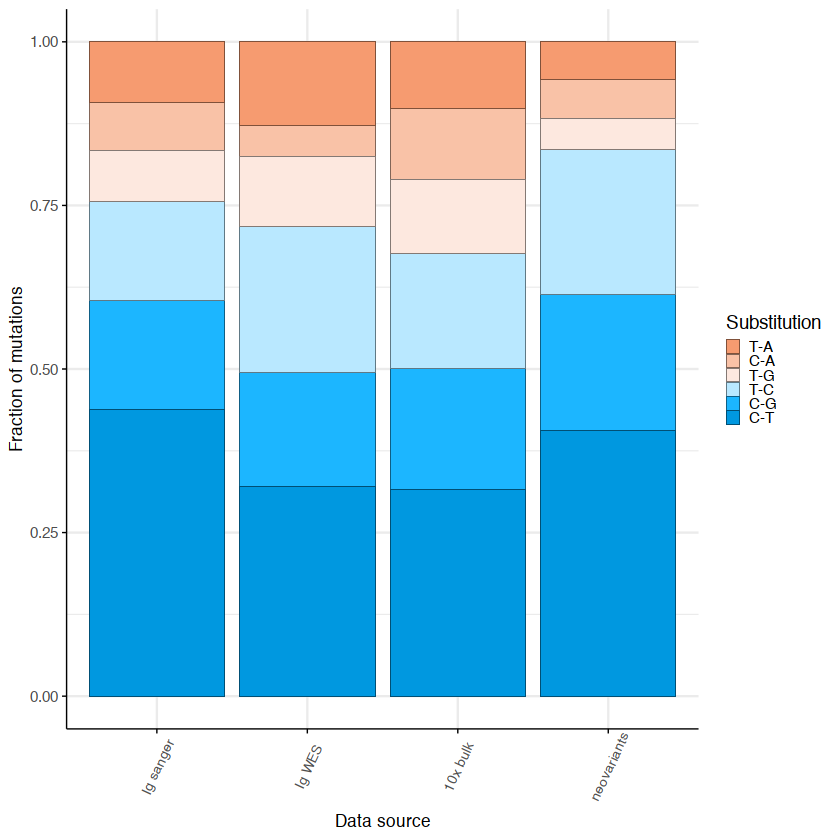

In [141]:
data <- spectro_combine

# Replace underscores in the 'source' labels
data$source <- gsub("_", " ", data$source)

# Reorder the 'substitution' factor according to your specified order for the plot
data$substitution <- factor(data$substitution, levels = c('T-A','C-A','T-G', 'T-C', 'C-G', 'C-T'))
data$source <- factor(data$source, levels = c('Ig sanger','Ig WES','10x bulk', 'neovariants'))

# Calculate the total counts for each source
totals <- data %>%
  group_by(source) %>%
  summarize(Total_n = sum(total_n), .groups = 'drop')

# Create the stacked bar plot
p <- ggplot(data, aes(x = source, y = Percentage, fill = substitution)) +
  geom_bar(stat = "identity", position = "fill",color="black",linewidth=0.1) +
  #geom_text(data = totals, aes(x = source, label = Total_n), vjust = 0, nudge_y = max(data$Percentage) * 0.05) +
  scale_fill_manual(values = c("#f69b70", "#f9c2a7", "#fde8df", "#b9e8ff", "#1cb6ff", "#0098e0")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 65, vjust = 0.6, size = 8), 
        axis.title = element_text(size = 10),
        plot.title = element_text(size = 12),
       axis.line = element_line(linewidt = 0.3, colour = "black", linetype=1),
       axis.ticks = element_line(size = 0.3, color="black"),
       legend.key.size = unit(0.3, 'cm')) +
  labs(x = "Data source", y = "Fraction of mutations", fill = "Substitution")



# Save the plot
#ggsave("figs_paper/substitution_spectrum_stacked_barplot.png", plot = p, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/substitution_spectrum_stacked_barplot.pdf", plot = p, width = 7, height = 7, units = "cm")

# Print the plot
print(p)


#### Chi-square exact test between neovariant and 10x bulk

source: https://statsandr.com/blog/fisher-s-exact-test-in-r-independence-test-for-a-small-sample/

In [142]:
# Create the 2x2 table in one step
chi_square_table <- spectro_combine %>%
  filter(source %in% c("10x_bulk", "neovariants")) %>%
  group_by(source) %>%
  summarize(
    total_subs = sum(total_n),
    ct = sum(total_n[substitution == "C-T"])
  ) %>%  column_to_rownames(var = "source")

chi_square_table

,total_subs,ct
,<int>,<int>
10x_bulk,7459,2351
neovariants,1055,429


#### Expected frequencies

The Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [143]:
chisq.test(chi_square_table)$expected

,total_subs,ct
10x_bulk,7395.284,2414.7158
neovariants,1118.716,365.2842


In [144]:
chisq.test(chi_square_table)


	Pearson's Chi-squared test with Yates' continuity correction

data:  chi_square_table
X-squared = 16.708, df = 1, p-value = 4.361e-05


### Data for Hendrik (substitution by subject)

In [145]:
spectro_10x <- KBall_subs_subject %>% bind_rows(spectro_subject)

In [146]:
spectro_10x <- spectro_10x %>% mutate(Patient_id = str_extract(subject, "S\\d+")) %>% group_by(Patient_id,source,substitution) %>%
  summarise(total_n=sum(n)) %>%  mutate(Percentage=total_n * 100 / sum(total_n))

`summarise()` has grouped output by 'Patient_id', 'source'. You can override
using the `.groups` argument.


In [147]:
head(spectro_10x)

Patient_id,source,substitution,total_n,Percentage
<chr>,<chr>,<chr>,<int>,<dbl>
S10000,10x_bulk,C-A,151,12.08
S10000,10x_bulk,C-G,251,20.08
S10000,10x_bulk,C-T,340,27.20
S10000,10x_bulk,T-A,153,12.24
S10000,10x_bulk,T-C,206,16.48
S10000,10x_bulk,T-G,149,11.92


In [148]:
# WriteXLS::WriteXLS(spectro_10x,
#                     "output/substitution_spectrum_10x.xlsx" )

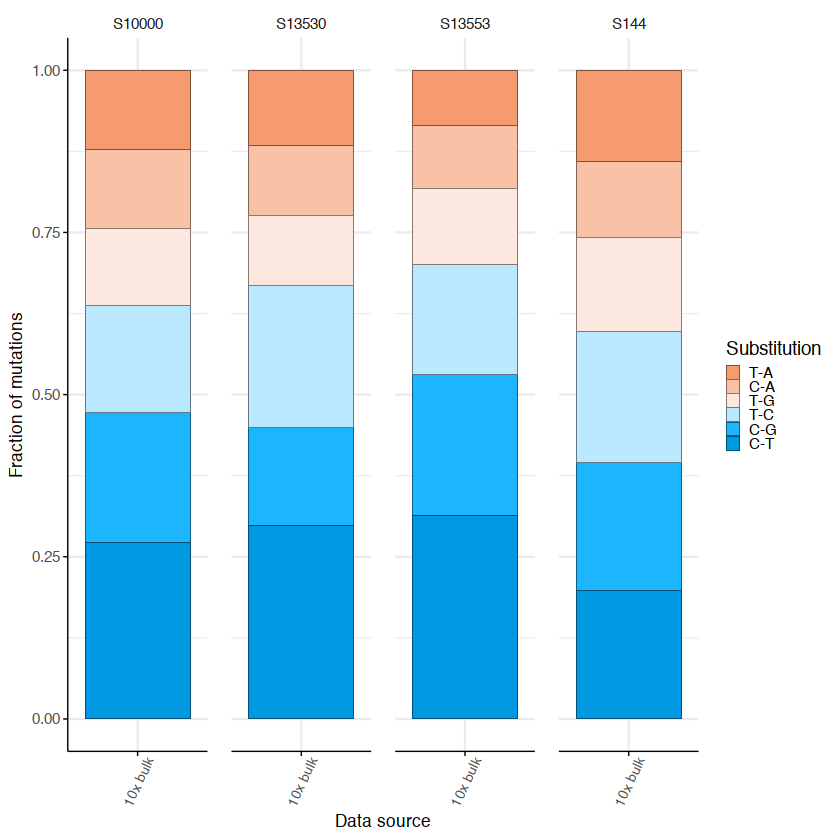

In [149]:
data <- spectro_10x

# Replace underscores in the 'source' labels
data$source <- gsub("_", " ", data$source)

# Reorder the 'substitution' factor according to your specified order for the plot
data$substitution <- factor(data$substitution, levels = c('T-A','C-A','T-G', 'T-C', 'C-G', 'C-T'))

# Calculate the total counts for each source
totals <- data %>%
  group_by(Patient_id) %>%
  summarize(Total_n = sum(total_n), .groups = 'drop')

# Create the stacked bar plot
p <- ggplot(data %>% filter(Patient_id %in% c("S10000","S13530","S13553", "S144")), aes(x = source, y = Percentage, fill = substitution)) +
  geom_bar(stat = "identity", position = "fill",color="black",linewidth=0.1) +
  #geom_text(data = totals, aes(x = source, label = Total_n), vjust = 0, nudge_y = max(data$Percentage) * 0.05) +
  scale_fill_manual(values = c("#f69b70", "#f9c2a7", "#fde8df", "#b9e8ff", "#1cb6ff", "#0098e0")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 65, vjust = 0.6, size = 8), 
        axis.title = element_text(size = 10),
        plot.title = element_text(size = 12),
       axis.line = element_line(linewidt = 0.3, colour = "black", linetype=1),
       axis.ticks = element_line(size = 0.3, color="black"),
       legend.key.size = unit(0.3, 'cm'),
       panel.spacing = unit(1, "lines")) +
  labs(x = "Data source", y = "Fraction of mutations", fill = "Substitution") +
  facet_grid(. ~ Patient_id)



# Save the plot
#ggsave("figs_paper/substitution_spectrum_stacked_barplot.png", plot = p, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/substitution_spectrum_stacked_barplot_subject.pdf", plot = p, width = 10.5, height = 7, units = "cm")

# Print the plot
print(p)


#### Chi-square test by subject with more than 100 events

source: https://statsandr.com/blog/fisher-s-exact-test-in-r-independence-test-for-a-small-sample/

#### Expected frequencies

The Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [150]:
# Function to create a 2x2 table and calculate expected frequencies
calculate_expected_frequencies <- function(sub_df) {
  chi_table <- sub_df %>%
    group_by(source) %>%
    summarize(
      Sum_Total_N = sum(total_n),
      CT_Total_N = sum(total_n[substitution == "C-T"])
    ) %>%
    column_to_rownames(var = "source")
  
  test_result <- chisq.test(chi_table)
  return(as.data.frame(test_result$expected))
}

# Split the data by patient_id and apply the function
expected_freqs <- spectro_10x %>% filter(Patient_id %in% c("S10000","S13530","S13553", "S144")) %>%
  split(.$Patient_id) %>%
  map_df(~ calculate_expected_frequencies(.x), .id = "Patient_id")

# View the expected frequencies DataFrame
print(expected_freqs)


  Patient_id test_result$expected
1     S10000                795.0
2     S10000                795.0
3     S13530                824.0
4     S13530                824.0
5     S13553                536.0
6     S13553                536.0
7       S144                251.5
8       S144                251.5


There are above 5 it should be apply chi-square

In [151]:
# Function to create a 2x2 table and perform chi-square test
perform_chi_square <- function(sub_df) {
  chi_table <- sub_df %>%
    group_by(source) %>%
    summarize(
      Sum_Total_N = sum(total_n),
      CT_Total_N = sum(total_n[substitution == "C-T"])
    ) %>%
    column_to_rownames(var = "source")

  chisq.test(chi_table)$p.value
}

# Split the data by patient_id and apply the function
p_values <- spectro_10x %>% filter(Patient_id %in% c("S10000","S13530","S13553", "S144")) %>%
  split(.$Patient_id) %>%
  map_dbl(~ perform_chi_square(.x))

# Create a summary table of p-values
summary_table <- data.frame(patient_id = names(p_values), p_value = p_values)

# View the summary table
summary_table

,patient_id,p_value
,<chr>,<dbl>
S10000,S10000,2.809702e-115
S13530,S13530,5.238489e-107
S13553,S13553,1.392217e-65
S144,S144,4.954169e-51


## Analysis 2025

In [5]:
ev <- readxl::read_excel("output/working_table.v5.3.xlsx")

#### Calculate AID motif by case

In [6]:
options(repr.matrix.max.cols = 100)
head(ev)

order,Chip,Sample,n_cell_ID,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,cell,region,subregion,position,jgene_position,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_po_coding_strand,context_cc_po,variation_delete,original_aid_motif,neovariant_aid_motif,motif_destroyed_original,strand_of_motif,motif_destroyed_neovariant,VDJ_position,vgene_position_aligned,dgene_position
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,K1B,S144,144.1,L,1,0,1,FALSE,AACCGCGAGGTGCTAG,V,FR2,262,NA,A,A,C,NA,32,52,NA,TRUE,4.176953,XAG,K,Q,NA,missense,CTAAG,CTAAG,A-C,WA,None,TRUE,coding,No_motif,133,133,NA
2,K1B,S144,144.2,L,1,0,1,FALSE,AACTCAGCATTCGACA,V,FR1,167,NA,A,A,T,NA,10,17,NA,TRUE,4.298879,XTC,I,F,NA,missense,CCATC,CCATC,A-T,None,WA,No_motif,No-motif,TRUE,61,61,NA
3,K1B,S144,144.3,L,3,0,3,FALSE,AAGGTTCGTTGTACAC,V,CDR3,395,NA,T,T,C,NA,10,17,NA,TRUE,4.298879,CXA,L,P,NA,missense,TCTAC,TCTAC,T-C,WA,None,TRUE,non-coding,No_motif,266,266,NA
4,K1B,S144,144.3,L,3,0,3,FALSE,AAGGTTCGTTGTACAC,V,FR2,230,NA,G,G,C,NA,17,23,NA,TRUE,3.703397,GXC,G,A,NA,missense,AGGCT,AGGCT,G-C,WRCY,WRCY,FALSE,non-coding,FALSE,101,101,NA
5,K1B,S144,144.3,L,3,0,3,FALSE,AAGGTTCGTTGTACAC,V,FR2,262,NA,A,A,C,NA,17,23,NA,TRUE,3.703397,XAG,K,Q,NA,missense,CTAAG,CTAAG,A-C,WA,None,TRUE,coding,No_motif,133,133,NA
6,K1B,S144,144.4,L,2,0,2,FALSE,ACACCCTCACACCGCA,V,FR1,152,NA,G,G,A,NA,24,19,NA,TRUE,2.523907,XGA,G,R,NA,missense,TAGGA,TAGGA,G-A,None,WA,No_motif,No-motif,TRUE,46,46,NA


In [12]:
ev %>% filter(cell == "CGTAGGCAGCGCTCCA")

order,Chip,Sample,n_cell_ID,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,cell,region,subregion,position,jgene_position,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_po_coding_strand,context_cc_po,variation_delete,original_aid_motif,neovariant_aid_motif,motif_destroyed_original,strand_of_motif,motif_destroyed_neovariant,VDJ_position,vgene_position_aligned,dgene_position
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
694,K6B,S13530,13530.30,H,6,3,0,TRUE,CGTAGGCAGCGCTCCA,J,CDR3,463,15,C,C,A,NA,60,44,NA,TRUE,2.380648,CTX,L,L,NA,silent,CTCTG,CTCTG,C-A,None,WA,No_motif,No-motif,TRUE,15,NA,NA
695,K6B,S13530,13530.30,H,6,3,0,TRUE,CGTAGGCAGCGCTCCA,V,FR3,320,NA,G,NA,A,G,NA,55,39,TRUE,NA,XAC,NA,N,D,NA,CAGAC,NA,NA,Not_evaluated,Not_evaluated,No_evaluated,Not_evaluated,No_evaluated,184,184,NA
696,K6B,S13530,13530.30,H,6,3,0,TRUE,CGTAGGCAGCGCTCCA,V,FR3,346,NA,C,NA,C,T,NA,53,38,TRUE,NA,ATX,NA,I,I,NA,ATCTC,NA,NA,Not_evaluated,Not_evaluated,No_evaluated,Not_evaluated,No_evaluated,210,210,NA
697,K6B,S13530,13530.30,L,6,0,3,TRUE,CGTAGGCAGCGCTCCA,V,FR1,163,NA,C,T,C,NA,19,53,NA,TRUE,5.765994,TGX,C,C,NA,silent,TGCCA,TGTCA,T-C,None,WRCY,No_motif,No-motif,TRUE,66,66,NA
698,K6B,S13530,13530.30,L,6,0,3,TRUE,CGTAGGCAGCGCTCCA,V,CDR1,187,NA,T,T,C,NA,21,52,NA,TRUE,5.392523,TAX,Y,Y,NA,silent,TATTA,TATTC,T-C,WA,WRCY,TRUE,non-coding,TRUE,90,90,NA
699,K6B,S13530,13530.30,L,6,0,3,TRUE,CGTAGGCAGCGCTCCA,V,FR2,196,NA,C,C,T,NA,20,50,NA,TRUE,5.422066,AGX,S,S,NA,silent,AGCTG,AGCTG,C-T,WRCY,WA,TRUE,coding,TRUE,99,99,NA


In [7]:
AID_sample <- ev %>%
  group_by(Sample) %>%
  summarise(
    total = n(),
    original_AID_motif = sum(original_aid_motif != "None")
  )

In [13]:
AID_sample

Sample,total,original_AID_motif
<chr>,<int>,<int>
S10000,394,212
S11770,1,1
S12500,2,0
S13530,400,208
S13553,322,226
S144,116,60
S8934,4,3


#### Calculate AID by experiment and sample

In [8]:
AID_sample <- ev %>%
  group_by(Chip,Sample) %>%
  summarise(
    total = n(),
    original_AID_motif = sum(original_aid_motif != "None")
  )

`summarise()` has grouped output by 'Chip'. You can override using the
`.groups` argument.


In [9]:
AID_sample

Chip,Sample,total,original_AID_motif
<chr>,<chr>,<int>,<int>
K1B,S10000,4,1
K1B,S144,116,60
K2B,S11770,1,1
K2B,S12500,2,0
K2B,S13530,5,2
K2B,S13553,11,9
K4B,S8934,3,2
K5B,S8934,1,1
K6B,S13530,395,206


#### Intra-sample reproducibility of detection of occurrent SHM events

In [47]:
shm_cell_patient <- events_v31  %>% mutate(experiment = str_sub(subject, 1, 2)) %>% 
   group_by(Sample,experiment) %>% 
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

`summarise()` has grouped output by 'Sample'. You can override using the
`.groups` argument.


Sample,experiment,neovariant_cells
<chr>,<chr>,<int>
S10000,K1,3
S10000,K7,125
S11770,K2,1
S12500,K2,1
S13530,K2,2
S13530,K6,85
S13553,K2,8
S13553,K8,95
S144,K1,40


In [54]:
intra <- case_cell %>% left_join(shm_cell_patient, by = c("Patient_id"="Sample", "experiment" = "experiment")) %>%
         group_by(Patient_id) %>%
         filter(n_distinct(experiment) > 1) %>%
         ungroup() %>%
         mutate(neovariant_cells = replace_na(neovariant_cells, 0)) %>%
         mutate(fraction = (neovariant_cells/total_cell)*100) %>%
         filter(!(Patient_id == "S8934" & experiment %in% c("K1", "K3"))) %>%
         group_by(Patient_id) %>%
         mutate(chip = row_number()) %>%
         ungroup()

intra$Biopsy <- c("same", "same", "different","different","same","same","same", "same","different","different")
intra

diagnosis,Patient_id,experiment,total_cell,neovariant_cells,fraction,chip,Biopsy
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>
FL,S10000,K1,1614,3,0.18587361,1,same
FL,S10000,K7,7343,125,1.70230151,2,same
FL,S12500,K2,1465,1,0.06825939,1,different
FL,S12500,K3,1024,0,0.00000000,2,different
FL,S13530,K2,1985,2,0.10075567,1,same
FL,S13530,K6,6422,85,1.32357521,2,same
FL,S13553,K2,1005,8,0.79601990,1,same
FL,S13553,K8,7217,95,1.31633643,2,same
FL,S8934,K4,7031,3,0.04266818,1,different


In [64]:
umi_counts <- df_seq %>% mutate(case = str_extract(subject, "(?<=S)\\d+")) %>%
              mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject))) %>%
              group_by(cell,case,gene) %>%
              summarise(umi_count = n(), gene = first(gene)) %>%
              ungroup()

`summarise()` has grouped output by 'cell', 'case'. You can override using the
`.groups` argument.


In [52]:
plot_data

Patient_id,fraction_1,fraction_2
<chr>,<dbl>,<dbl>
S10000,0.18587361,1.70230151
S12500,0.06825939,0.00000000
S13530,0.10075567,1.32357521
S13553,0.79601990,1.31633643
S8934,0.04266818,0.01524855


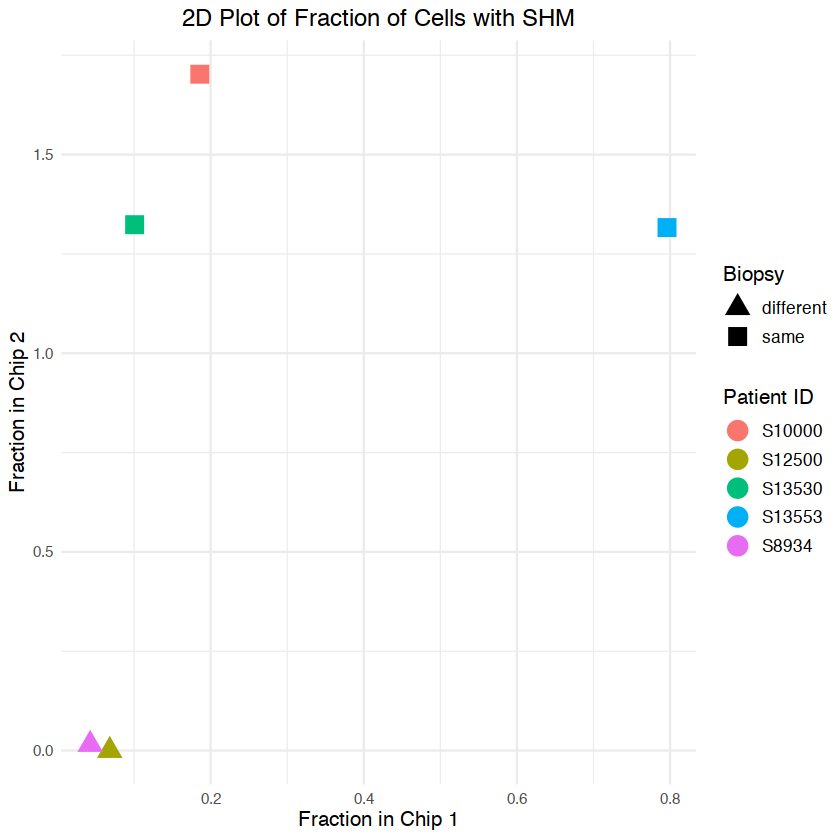

In [56]:
# Prepare data for plotting
plot_data <- intra %>%
  select(Patient_id, chip, fraction,Biopsy) %>%
  pivot_wider(
    names_from = chip,
    values_from = fraction,
    names_prefix = "fraction_"
  )


# Create the scatter plot with coloring by Patient_id
ggplot(plot_data, aes(x = fraction_1, y = fraction_2, color = Patient_id, shape = Biopsy)) +
  geom_point(size = 5) +
  scale_shape_manual(values = c("same" = 15, "different" = 17)) +  # Assign shapes
  labs(
    title = "2D Plot of Fraction of Cells with SHM",
    x = "Fraction in Chip 1",
    y = "Fraction in Chip 2",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  )

#### Number of false cell in cell ranger

In [50]:
# Step 1: Read the single CSV file
folder_path <- "input/all_contig_annotations.csv"  # Adjusted for the specific file

# Step 2: List all CSV files in the folder
files <- list.files(folder_path, pattern = "\\.csv$", full.names = TRUE)

# Step 3: Read each file, select the required columns, and add the file prefix as a new column
data_list <- lapply(files, function(file) {
  # Read the CSV file
  df <- read.csv(file)
  
  # Select the required columns
  df <- df %>%
#    select(barcode, is_cell, high_confidence) %>%  # Select specific columns
    mutate(file_prefix = substr(basename(file), 1, 3))  # Add the first 3 characters of the file name
  
  return(df)
})

# Step 4: Combine all dataframes into one
combined_df <- bind_rows(data_list)


In [51]:
# Convert columns to lowercase
combined_df$is_cell <- tolower(combined_df$is_cell)
combined_df$high_confidence <- tolower(combined_df$high_confidence)

In [54]:
combined_df %>% filter(barcode == "ACGCCAGAGGCATTGG-1")

barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,⋯,cdr1_nt,fwr2,fwr2_nt,cdr2,cdr2_nt,fwr3,fwr3_nt,fwr4,fwr4_nt,exact_subclonotype_id
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
ACGCCAGAGGCATTGG-1,false,ACGCCAGAGGCATTGG-1_contig_1,false,557,IGK,IGKV1-17,None,IGKJ4,IGKC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ACGCCAGAGGCATTGG-1,false,ACGCCAGAGGCATTGG-1_contig_2,false,551,IGK,IGKV1-17,None,IGKJ4,IGKC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ACGCCAGAGGCATTGG-1,false,ACGCCAGAGGCATTGG-1_contig_3,false,590,IGH,IGHV3-30,None,IGHJ6,IGHM,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ACGCCAGAGGCATTGG-1,false,ACGCCAGAGGCATTGG-1_contig_4,true,476,IGL,None,None,IGLJ1,IGLC1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [48]:
# Remove last two characters from barcode
combined <- combined_df %>%
  mutate(cell = str_sub(barcode, 1, -3)) %>%
  select(cell, is_cell, high_confidence,Chip = file_prefix)

# Filter to retain only rows that exist in df2
filtered_df <- combined %>%
  semi_join(ev, by = c("cell", "Chip")) %>% distinct()

In [49]:
filtered_df$duplicated_cell <- duplicated(filtered_df$cell) | duplicated(filtered_df$cell, fromLast = TRUE)

# View the result
head(filtered_df)


,cell,is_cell,high_confidence,Chip,duplicated_cell
,<chr>,<chr>,<chr>,<chr>,<lgl>
1,AACCGCGAGGTGCTAG,true,true,K1B,FALSE
2,AAGGTTCGTTGTACAC,true,true,K1B,FALSE
3,ACACCCTCACACCGCA,true,true,K1B,FALSE
4,ACTTACTGTAGAGGAA,true,true,K1B,FALSE
5,AGCTTGACAATGGACG,true,true,K1B,FALSE
6,AGGTCATCAGTTCCCT,true,true,K1B,FALSE


In [44]:
filtered_df %>% filter(duplicated_cell ==  TRUE)

cell,is_cell,high_confidence,Chip,duplicated_cell
<chr>,<chr>,<chr>,<chr>,<lgl>
ACGCCAGAGGCATTGG,false,false,K1B,TRUE
ACGCCAGAGGCATTGG,false,true,K1B,TRUE
CATGACAGTGTCAATC,false,false,K1B,TRUE
CATGACAGTGTCAATC,false,true,K1B,TRUE
TGCGTGGCACAAGACG,false,false,K1B,TRUE
TGCGTGGCACAAGACG,false,true,K1B,TRUE
TTATGCTCATCCTTGC,false,false,K1B,TRUE
TTATGCTCATCCTTGC,false,true,K1B,TRUE
CAGTAACCATATGGTC,false,false,K2B,TRUE


In [40]:
head(filtered_df)

,cell,is_cell,high_confidence,Chip
,<chr>,<chr>,<chr>,<chr>
1,AACCGCGAGGTGCTAG,true,true,K1B
2,AAGGTTCGTTGTACAC,true,true,K1B
3,ACACCCTCACACCGCA,true,true,K1B
4,ACTTACTGTAGAGGAA,true,true,K1B
5,AGCTTGACAATGGACG,true,true,K1B
6,AGGTCATCAGTTCCCT,true,true,K1B


In [29]:
ev %>% pull(cell,Chip) %>% unique() %>% str()

 chr [1:364] "AACCGCGAGGTGCTAG" "AACTCAGCATTCGACA" "AAGGTTCGTTGTACAC" ...


In [26]:
result_is_cell <- filtered_df %>%
    distinct(cell, .keep_all = TRUE) %>%
  summarise(
    true_count = sum(is_cell == "true"),
    false_count = sum(is_cell == "false")
  )

result_is_cell

true_count,false_count
<int>,<int>
349,15


### Identify references cells

In [4]:
# df to extract the total number of cell with expression data
pd <- read.csv("output/expression_dna_repair_K12345678.csv") %>% select(cell, experiment)
head(pd)

,cell,experiment
,<chr>,<chr>
1,AAACCTGAGATCACGG,K1B
2,AAACCTGAGCCAGTTT,K1B
3,AAACCTGAGCGGCTTC,K1B
4,AAACCTGAGGCATGTG,K1B
5,AAACCTGAGTGTTTGC,K1B
6,AAACCTGCAACTGCTA,K1B


In [6]:
print("Total cells expression experiment")

pd %>% distinct() %>% nrow()

[1] "Total cells expression experiment"
 chr [1:89397] "AAACCTGAGATCACGG" "AAACCTGAGCCAGTTT" "AAACCTGAGCGGCTTC" ...


[1] 94615

#### are all the SHM cells on expression data?

In [7]:
# Find matches from df1 in df2 using semi_join
matched_df <- semi_join(df_summary, pd, by = "cell")

# Count the number of matches
num_matches <- nrow(matched_df)

# Print the result
print(paste("Number of matching rows:", num_matches))

ERROR: Error: object 'df_summary' not found


In [9]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

#### 1. Remove doublets

In [8]:
doublet <- read.csv("output/doublet_K12345678.csv")

In [9]:
print("Total cells doublet analysis")
doublet %>% distinct() %>% nrow()

print("Doublet cells")
doublet %>% filter(scDblFinder.class == "doublet") %>% distinct() %>% nrow()

[1] "Total cells doublet analysis"


[1] 94615

[1] "Doublet cells"


[1] 13080

In [10]:
# Select doublet cells and generated a df for anti_join
doublet_pos <- doublet %>% filter(scDblFinder.class == "doublet") %>% 
               select(experiment,cell) %>% mutate(group = "SHMss_not_observed")

In [11]:
# remove doublet (13080 cells)

cell_list1 <- cell_list %>%
  anti_join(doublet_pos)# remove possible false positives

ERROR: Error: object 'cell_list' not found


In [14]:
print("Total cells scRNA experimets AFTER filtering of doublet")
cell_list1 %>% filter(group == "SHMss_not_observed") %>% pull(cell) %>% str()

[1] "Total cells scRNA experimets AFTER filtering of doublet"
 chr [1:81171] "AAACCTGAGATCACGG" "AAACCTGAGCCAGTTT" "AAACCTGAGGCATGTG" ...


#### 2. We removed cells that could be false positive

In [15]:
print("number of cells with ssSHM")
df_summary %>% pull(cell) %>% unique() %>% str()

[1] "number of cells with ssSHM"
 chr [1:364] "AGCTTGACAATGGACG" "CTAGCCTCAATCACAC" "CGAGCACAGGTTCCTA" ...


In [64]:
# barcodes of cells with scSHM to filter the df with all the events
cells_SHM <- cell_list %>% filter(group == "SHMss_observed") %>% pull(cell)

In [17]:
# # Identify false positives from BCR data

# false_positives <- df %>% #all cells with events
#   filter(!cell %in% cells_SHM) %>% #revove of the list of false positives the real positive cells
#   mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
#   select(experiment, cell, group) %>%
#   distinct()

In [18]:
# print("number of false positive cells")
# false_positives %>% pull(cell) %>% str()

In [19]:
# remove possible false positives

cell_list2 <- cell_list1 %>%
#  right_join(df_complete_cells) %>% # retain cells with complete coverage of VDJ
  anti_join(false_positives)# remove possible false positives

ERROR: Error: object 'false_positives' not found


In [ ]:
print("Total cells scRNA experimets AFTER filtering of false positives")
cell_list2 %>% filter(group == "SHMss_not_observed") %>% pull(cell) %>% str()

#### 3. Filter cells with the same quality characteristics that scSHM (dataset: scBCR)

In [ ]:
# print("Total cells scBCR")
# df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,cell) %>% summarize(n = n(), sum_nreads=sum(nreads)) %>% 
# unique() %>% pull(cell) %>% str()

In [ ]:
head(df_seq)

In [89]:
df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% anti_join(doublet_pos) %>%  
summarize(n = n(), sum_nreads=sum(nreads)) %>% 
filter(n >=10, sum_nreads >= 50)  %>% select(experiment,cell) %>%
distinct(cell,experiment) %>% nrow()

Joining with `by = join_by(cell, experiment)`


[1] 75813

In [95]:
df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% anti_join(doublet_pos) %>%  
summarize(n = n(), sum_nreads=sum(nreads)) %>% 
filter(n >=10, sum_nreads >= 50)  %>% select(experiment,cell) %>%
distinct(cell,experiment) %>% nrow()

Joining with `by = join_by(cell, experiment)`
`summarise()` has grouped output by 'experiment', 'subject'. You can override using the `.groups` argument.
Adding missing grouping variables: `subject`


[1] 44069

In [98]:
str(cells_SHM)

 chr [1:364] "AGCTTGACAATGGACG" "CTAGCCTCAATCACAC" "CGAGCACAGGTTCCTA" ...


In [21]:
str(cells_SHM)

 chr [1:364] "AGCTTGACAATGGACG" "CTAGCCTCAATCACAC" "CGAGCACAGGTTCCTA" ...


In [36]:
# test_shm_cells <- df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% anti_join(doublet_pos) %>%  
# summarize(n = n(), mean_nreads = mean(nreads, na.rm = TRUE),  # Calculate the mean, excluding NA values
#     median_nreads = median(nreads, na.rm = TRUE)) %>% semi_join(df_summary, by = c("subject","cell"))

Joining with `by = join_by(cell, experiment)`
`summarise()` has grouped output by 'experiment', 'subject'. You can override
using the `.groups` argument.


In [16]:
# we take any cell with the HC o LC with the quality characteristics
quality_cells_count <- df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% 
summarize(n = n(), mean_nreads = mean(nreads, na.rm = TRUE), median_nreads = median(nreads, na.rm = TRUE)) %>% 
filter(n >=10, median_nreads >= 50) %>% 
anti_join(doublet_pos) %>%
mutate(case = str_extract(subject, "(?<=S)\\d+"), experiment = substr(subject, 1, 2)) %>%
              mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject))) 

`summarise()` has grouped output by 'experiment', 'subject'. You can override
using the `.groups` argument.
Joining with `by = join_by(experiment, cell)`


In [17]:
head(quality_cells_count)

experiment,subject,cell,n,mean_nreads,median_nreads,case,gene
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>
K1,K1B_S10000-HC,AACTGGTAGCCCAATT,16,173.9375,172.5,10000,HC
K1,K1B_S10000-HC,AAGGTTCTCCAGTATG,14,156.0000,152.0,10000,HC
K1,K1B_S10000-HC,ACAGCTATCTCCAGGG,13,177.5385,178.0,10000,HC
K1,K1B_S10000-HC,ACGCCGATCATCGATG,10,164.4000,165.5,10000,HC
K1,K1B_S10000-HC,AGAATAGAGCCACGCT,10,153.0000,157.5,10000,HC
K1,K1B_S10000-HC,AGAGTGGCATGACATC,13,179.6154,169.0,10000,HC


In [46]:
quality_cells <- df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% 
summarize(n = n(), sum_nreads=sum(nreads))

`summarise()` has grouped output by 'experiment', 'subject'. You can override
using the `.groups` argument.


In [144]:
sd <- df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% 
summarize(n = n(), sum_nreads=sum(nreads)) 

`summarise()` has grouped output by 'experiment', 'subject'. You can override
using the `.groups` argument.


In [146]:
df_seq %>% filter(cell == "AAACCTGAGTGTTTGC")

cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC


In [147]:
head(quality_cells)

experiment,cell,group
<chr>,<chr>,<chr>
K1B,AACTGGTAGCCCAATT,SHMss_not_observed
K1B,AAGGTTCTCCAGTATG,SHMss_not_observed
K1B,ACAGCTATCTCCAGGG,SHMss_not_observed
K1B,ACGCCGATCATCGATG,SHMss_not_observed
K1B,AGAATAGAGCCACGCT,SHMss_not_observed
K1B,AGAGTGGCATGACATC,SHMss_not_observed


In [85]:
biopsy_sou <- read.csv("input/biopsy_source.csv")
biopsy_sou

sample,type,source,experiment
<chr>,<chr>,<chr>,<chr>
S144,mutiplex,LN,K1
S8382,mutiplex,LN,K3
S8934,mutiplex,LN1,K1
S8934,mutiplex,LN2,K3
S10000,mutiplex,LN,K1
S10971,mutiplex,LN,K1
S11770,mutiplex,LN,K2
S12118,mutiplex,LN,K2
S12282,mutiplex,LN,K1


In [76]:
umi_counts <- df_seq %>% filter(cell %in% quality_cells$cell) %>%
              mutate(case = str_extract(subject, "(?<=S)\\d+"), experiment = substr(subject, 1, 2)) %>%
              mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject))) %>%
              group_by(cell,case,experiment,gene) %>%
              summarise(umi_count = n(), gene = first(gene)) %>%
              ungroup()

`summarise()` has grouped output by 'cell', 'case', 'experiment'. You can
override using the `.groups` argument.


In [77]:
head(umi_counts)

cell,case,experiment,gene,umi_count
<chr>,<chr>,<chr>,<chr>,<int>
AAACCTGAGAAACCGC,10000,K7,HC,21
AAACCTGAGAAACCGC,10000,K7,LC,16
AAACCTGAGAAAGTGG,13553,K8,HC,3
AAACCTGAGAAAGTGG,13553,K8,LC,56
AAACCTGAGACCGGAT,13530,K6,HC,52
AAACCTGAGACCGGAT,13530,K6,LC,66


In [18]:
head(quality_cells_count)

experiment,subject,cell,n,mean_nreads,median_nreads,case,gene
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>
K1,K1B_S10000-HC,AACTGGTAGCCCAATT,16,173.9375,172.5,10000,HC
K1,K1B_S10000-HC,AAGGTTCTCCAGTATG,14,156.0000,152.0,10000,HC
K1,K1B_S10000-HC,ACAGCTATCTCCAGGG,13,177.5385,178.0,10000,HC
K1,K1B_S10000-HC,ACGCCGATCATCGATG,10,164.4000,165.5,10000,HC
K1,K1B_S10000-HC,AGAATAGAGCCACGCT,10,153.0000,157.5,10000,HC
K1,K1B_S10000-HC,AGAGTGGCATGACATC,13,179.6154,169.0,10000,HC


In [143]:
# Summarize counts by case and calculate the counts per cell for HC and LC
summary_counts <- quality_cells_count %>% group_by(experiment, cell) %>%
  mutate(
    has_HC = gene == "HC",  # Flag for HC gene
    has_LC = gene == "LC"   # Flag for LC gene
  ) %>%
  group_by(case,experiment, cell) %>% # First group by cell within each case
  summarise(
    has_HC = any(has_HC),   # Check if this cell has HC
    has_LC = any(has_LC),   # Check if this cell has LC
    .groups = "drop"         # Drop the grouping after cell summary
  ) %>%
  group_by(case,experiment) %>% # Now group by case to summarize across all cells within a case
  summarise(
    total_cells = n_distinct(cell),          # Total unique cells per case
    VDJ_only = sum(has_HC & !has_LC),        # Cells with only HC
    VJ_only = sum(has_LC & !has_HC),         # Cells with only LC
    VDJ_and_VJ = sum(has_HC & has_LC),       # Cells with both HC and LC
    VDJ_and_or_VJ = sum(has_HC | has_LC)     # Cells with either HC or LC
  )

# View the summarized data
print(summary_counts)


`summarise()` has grouped output by 'case'. You can override using the
`.groups` argument.


# A tibble: 18 × 7
# Groups:   case [11]
   case  experiment total_cells VDJ_only VJ_only VDJ_and_VJ VDJ_and_or_VJ
   <chr> <chr>            <int>    <int>   <int>      <int>         <int>
 1 10000 K1                 899        0     855         44           899
 2 10000 K7                5019      105     833       4081          5019
 3 10971 K1                  12        0      12          0            12
 4 11770 K2                   1        0       1          0             1
 5 12118 K2                 347       19     299         29           347
 6 12282 K1                 178        0     171          7           178
 7 12390 K3                   5        1       4          0             5
 8 12500 K2                1177      280     131        766          1177
 9 12500 K3                   9        9       0          0             9
10 13530 K2                1625       17     425       1183          1625
11 13530 K6                5198       84      58       5056          51

In [29]:
# Summarize counts by case and calculate the counts per cell for HC and LC
summary_counts <- quality_cells_count %>%
  group_by(experiment, cell) %>%
  mutate(
    has_HC = gene == "HC",  # Flag for HC gene
    has_LC = gene == "LC"   # Flag for LC gene
  ) %>%
  group_by(experiment, cell) %>%  # Group by experiment and cell for proper summarization
  summarise(
    has_HC = any(has_HC),   # Check if this cell has HC
    has_LC = any(has_LC),   # Check if this cell has LC
    .groups = "drop"         # Drop the grouping after cell summary
  ) %>%
  summarise(
    total_cells = n_distinct(cell),          # Total unique cells per experiment
    VDJ_only = sum(has_HC & !has_LC),        # Cells with only HC
    VJ_only = sum(has_LC & !has_HC),         # Cells with only LC
    VDJ_and_VJ = sum(has_HC & has_LC),       # Cells with both HC and LC
    .groups = "drop"
  )

# Count unique (cell, experiment) pairs in summary_counts
summary_unique_pairs <- summary_counts %>%
  summarise(total_validated = sum(total_cells), .groups = "drop") %>%
  pull(total_validated)

# Final Validation
if (original_unique_pairs$n == summary_unique_pairs) {
  print("✅ Validation Passed: Total (cell, experiment) counts match!")
} else {
  print(paste("❌ Validation Failed: Expected", original_unique_pairs$n, "but got", summary_unique_pairs))
}



ERROR: Error in if (original_unique_pairs$n == summary_unique_pairs) {: the condition has length > 1


In [30]:
summary_counts

total_cells,VDJ_only,VJ_only,VDJ_and_VJ
<int>,<int>,<int>,<int>
29126,546,15889,13230


In [31]:
# Count unique (cell, experiment) pairs in the original dataset
original_unique_pairs <- quality_cells_count %>%
  distinct(cell, experiment) %>%
  tally() %>%
  pull(n)  # Extract the count as a single value

# Count unique (cell, experiment) pairs in summary_counts
summary_unique_pairs <- summary_counts %>%
  summarise(total_validated = sum(total_cells), .groups = "drop") %>%
  pull(total_validated)

# Final validation of counts
if (original_unique_pairs == summary_unique_pairs) {
  print("✅ Validation Passed: Total (cell, experiment) counts match!")
} else {
  print(paste("❌ Validation Failed: Expected", original_unique_pairs, "but got", summary_unique_pairs))
}


ERROR: Error in if (original_unique_pairs == summary_unique_pairs) {: the condition has length > 1


In [25]:
# Count unique (cell, experiment) pairs in the original dataset
total_unique_cells <- quality_cells_count %>% 
  summarise(total_cells = n_distinct(paste(cell, experiment, sep = "_")), .groups = "drop") %>% 
  pull(total_cells) %>% 
  sum()  # Ensure a single numeric value

# Sum total_cells from summary_counts
validated_total <- summary_counts %>% 
  summarise(total_validated = sum(total_cells), .groups = "drop") %>% 
  pull(total_validated) %>% 
  sum()  # Ensure a single numeric value

# Validation check
if (total_unique_cells == validated_total) {
  print("✅ Validation Passed: Total (cell, experiment) counts match!")
} else {
  print(paste("❌ Validation Failed: Expected", total_unique_cells, "but got", validated_total))
}


[1] "❌ Validation Failed: Expected 42895 but got 29665"


In [26]:
# Count unique (cell, experiment) pairs in the original dataset
original_unique_pairs <- quality_cells_count %>%
  distinct(cell, experiment) %>%
  tally() 

print(original_unique_pairs)


# A tibble: 31 × 3
# Groups:   experiment [8]
   experiment subject           n
   <chr>      <chr>         <int>
 1 K1         K1B_S10000-HC    44
 2 K1         K1B_S10000-LC   899
 3 K1         K1B_S10971-LC    12
 4 K1         K1B_S12282-HC     7
 5 K1         K1B_S12282-LC   178
 6 K1         K1B_S144-HC      39
 7 K1         K1B_S144-LC     930
 8 K1         K1B_S8934-HC      2
 9 K1         K1B_S8934-LC    576
10 K2         K2B_S11770-LC     1
# ℹ 21 more rows


In [27]:
original_unique_pairs

experiment,subject,n
<chr>,<chr>,<int>
K1,K1B_S10000-HC,44
K1,K1B_S10000-LC,899
K1,K1B_S10971-LC,12
K1,K1B_S12282-HC,7
K1,K1B_S12282-LC,178
K1,K1B_S144-HC,39
K1,K1B_S144-LC,930
K1,K1B_S8934-HC,2
K1,K1B_S8934-LC,576


In [167]:
quality_cells_count %>%       distinct(cell) %>% 
  summarise(total_unique_cells = n()) %>% pull (total_unique_cells) %>% sum()
sum(summary_counts$VDJ_and_or_VJ)

`summarise()` has grouped output by 'experiment'. You can override using the
`.groups` argument.


[1] 42895

[1] 29665

In [145]:
quality_cells <- quality_cells_count %>% anti_join(events_v31, by = c("cell", "experiment"="Chip"))

 chr [1:29126] "AACTGGTAGCCCAATT" "AAGGTTCTCCAGTATG" "ACAGCTATCTCCAGGG" ...


In [148]:
quality_cells

experiment,subject,cell,n,mean_nreads,median_nreads,case,gene
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>
K1,K1B_S10000-HC,AACTGGTAGCCCAATT,16,173.9375,172.5,10000,HC
K1,K1B_S10000-HC,AAGGTTCTCCAGTATG,14,156.0000,152.0,10000,HC
K1,K1B_S10000-HC,ACAGCTATCTCCAGGG,13,177.5385,178.0,10000,HC
K1,K1B_S10000-HC,ACGCCGATCATCGATG,10,164.4000,165.5,10000,HC
K1,K1B_S10000-HC,AGAATAGAGCCACGCT,10,153.0000,157.5,10000,HC
K1,K1B_S10000-HC,AGAGTGGCATGACATC,13,179.6154,169.0,10000,HC
K1,K1B_S10000-HC,AGATTGCTCGGCGGTT,16,164.8125,174.0,10000,HC
K1,K1B_S10000-HC,ATAAGAGTCTCCAACC,10,141.5000,156.0,10000,HC
K1,K1B_S10000-HC,ATCACGACAATAGAGT,21,154.2381,161.0,10000,HC


In [149]:
cells_K6_8 <- quality_cells %>% filter(experiment %in% c("K6","K7","K8"))

In [151]:
write.csv(cells_K6_8, "output/reference_cells_k6-8.csv", row.names = FALSE)